# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
MagneticCase = 'NM'
from importlib.machinery import SourceFileLoader

In [4]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester
Dataset = SourceFileLoader('Dataset', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset

In [5]:
DS = Dataset('Fe-Mo', selectMag=MagneticCase)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
Fe_pv4Mo_sv8.C14-ABB.NM,bulk C14-ABB,15.245244 A,-9.319758,207.464779 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,8,0,12.0,0.333333,0.666667,0.721529,C14
Fe_pv2Mo_sv4.C15-AB2.NM,bulk C15-AB2,15.274882 A,-9.344259,208.545221 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,2,4,0,6.0,0.333333,0.666667,0.697028,C15
Fe_pv8Mo_sv16.C36-AABBB.NM,bulk C36-AABBB,15.278026 A,-9.327170,208.733130 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,16,0,24.0,0.333333,0.666667,0.714117,C36
Fe_pv14Mo_sv10.C36-AABAB.NM,bulk C36-AABAB,13.743087 A,-8.672992,211.069684 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,14,10,0,24.0,0.583333,0.416667,0.698547,C36
Fe_pv4Mo_sv9.mu-BBAAB.NM,bulk mu-BBAAB,15.248689 A,-9.447215,214.642550 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,9,0,13.0,0.307692,0.692308,0.662764,mu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,25,4,0,29.0,0.862069,0.137931,0.119258,chi
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,16,8,0,24.0,0.666667,0.333333,0.030551,C36
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,4,0,12.0,0.666667,0.333333,0.015189,C14
Fe_pv4.fcc-cubic.NM,bulk fcc-cubic,10.248696 A,-8.104999,283.740438 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,4,0,0,4.0,1.000000,0.000000,0.150295,fcc


Possible models are: **Kernel Ridge, MLP and Random Forest**

In [7]:
ModelName = f'Kernel Ridge {MagneticCase}'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


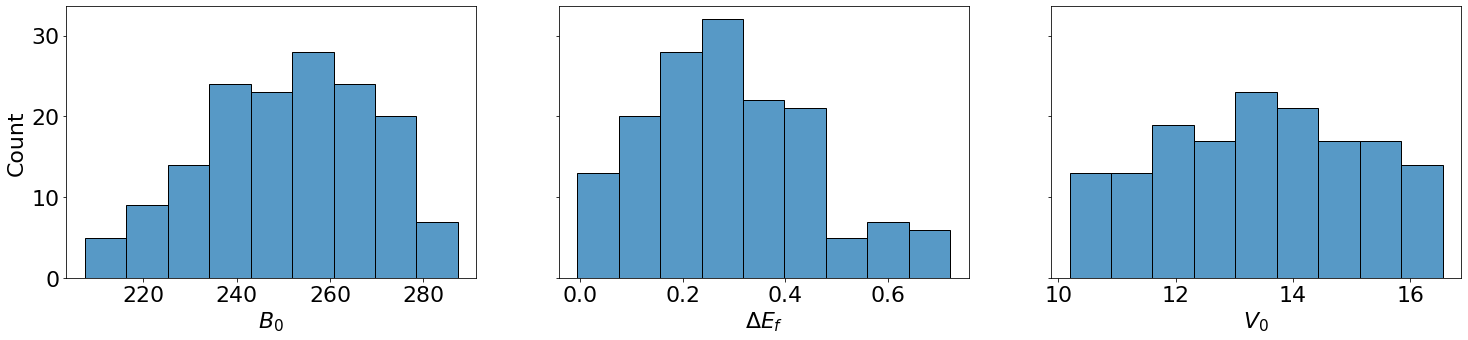

In [8]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions.eps')

# Machine Learning 

In [9]:
from Tools.DatasetTools.MLConveniences import *

In [10]:
resultslocation = DS.resultslocation

## Feature sets

In [11]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [12]:
Features['SOAP_canonicalW'].filter(regex='_0').columns

Index(['SOAP_4_0', 'SOAP_5_0', 'SOAP_6_0', 'SOAP_7_0', 'SOAP_20_0',
       'SOAP_30_0', 'SOAP_31_0', 'SOAP_35_0', 'SOAP_38_0', 'SOAP_304_0',
       'SOAP_305_0', 'SOAP_306_0', 'SOAP_308_0'],
      dtype='object')

In [13]:
Features['SOAP_canonicalFe'].filter(regex='_0').columns

Index(['SOAP_4_0', 'SOAP_5_0', 'SOAP_6_0', 'SOAP_7_0', 'SOAP_20_0',
       'SOAP_30_0', 'SOAP_31_0', 'SOAP_35_0', 'SOAP_38_0', 'SOAP_304_0',
       'SOAP_305_0', 'SOAP_306_0', 'SOAP_308_0'],
      dtype='object')

In [14]:
Features['SOAP_specific'].filter(regex='_0').columns

Index(['SOAP_1_0', 'SOAP_2_0', 'SOAP_3_0', 'SOAP_4_0', 'SOAP_5_0', 'SOAP_6_0',
       'SOAP_7_0', 'SOAP_8_0', 'SOAP_17_0', 'SOAP_18_0', 'SOAP_19_0',
       'SOAP_20_0', 'SOAP_21_0', 'SOAP_22_0', 'SOAP_23_0', 'SOAP_25_0',
       'SOAP_29_0', 'SOAP_30_0', 'SOAP_31_0', 'SOAP_33_0', 'SOAP_34_0',
       'SOAP_35_0', 'SOAP_38_0', 'SOAP_43_0', 'SOAP_44_0', 'SOAP_306_0',
       'SOAP_308_0', 'SOAP_309_0', 'SOAP_311_0', 'SOAP_313_0', 'SOAP_314_0',
       'SOAP_319_0', 'SOAP_320_0', 'SOAP_321_0', 'SOAP_322_0', 'SOAP_323_0',
       'SOAP_351_0', 'SOAP_360_0', 'SOAP_369_0', 'SOAP_378_0', 'SOAP_387_0',
       'SOAP_882_0', 'SOAP_883_0', 'SOAP_884_0', 'SOAP_885_0', 'SOAP_886_0',
       'SOAP_887_0', 'SOAP_888_0', 'SOAP_889_0', 'SOAP_890_0', 'SOAP_899_0',
       'SOAP_900_0', 'SOAP_901_0', 'SOAP_902_0', 'SOAP_903_0', 'SOAP_904_0',
       'SOAP_905_0', 'SOAP_907_0', 'SOAP_911_0', 'SOAP_912_0', 'SOAP_913_0',
       'SOAP_914_0', 'SOAP_916_0', 'SOAP_923_0', 'SOAP_925_0', 'SOAP_926_0',
       'SOAP_1187_

Text(0, 0.5, 'counts')

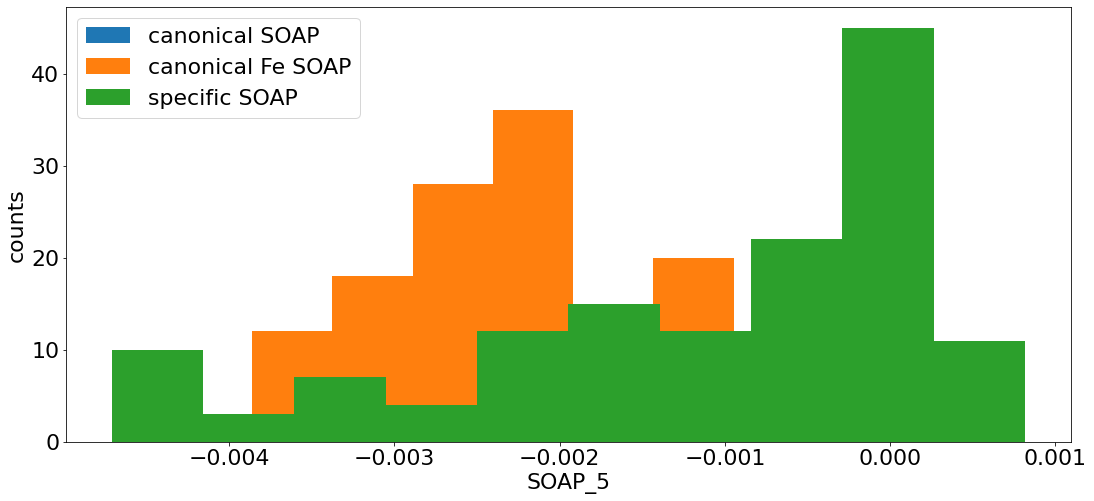

In [15]:
fig, ax = plt.subplots()
hist1 = plt.hist(Features['SOAP_canonicalW']['SOAP_5_0'], label='canonical SOAP')
hist1 = plt.hist(Features['SOAP_canonicalFe']['SOAP_5_0'], label='canonical Fe SOAP')
hist2 = plt.hist(Features['SOAP_specific']['SOAP_5_0'], label = 'specific SOAP')
ax.legend()
ax.set_xlabel('SOAP_5')
ax.set_ylabel('counts')

In [16]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_canonicalFe', 'SOAP_canonicalW', 'SOAP_specific', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [17]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [18]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [19]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [20]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [21]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [22]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [23]:
import warnings
warnings.simplefilter('ignore')

In [24]:
Models = {
    f'Kernel Ridge {MagneticCase}': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    f'MLP {MagneticCase}': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    f'Random Forest {MagneticCase}': Pipeline([('regressor', RandomForestRegressor())]),
    f'Gaussian Process {MagneticCase}': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [25]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [26]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

# fits

In [27]:
ModelName

'Kernel Ridge NM'

In [28]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_canonicalFe', 'SOAP_canonicalW', 'SOAP_specific', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP', 'Canonical BOP no CNAV', 'Projections BOP no CNAV', 'Projections OS BOP no CNAV', 'Projections sOS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + Projections BOP no CNAV', 'dataset + Projections OS BOP no CNAV', 'dataset + Projections sOS BOP no CNAV'])

In [29]:
#MO.save_model_options(ModelName, ModelOptions[ModelName])

MO.load_model_options(ModelName)

#MO.modeloptions[ModelName]

samplefolds = list(DS.get_folds())

fittedmodelslocation = os.path.join(DS.resultslocation, f'{ModelName}_FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)
else:
    FittedModels = {}

for name, model in Models.items():
    if name not in ModelName:
        print (name)
        continue
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        progress.set_description(key)
#        if 'BOP' not in key:
#            continue
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        print(key)
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

#with open(fittedmodelslocation, 'wb') as pkl:
#    pickle.dump(FittedModels, pkl)

  0%|          | 0/22 [00:00<?, ?it/s]

atomic
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_canonicalFe
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_canonicalW
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_specific
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Pyscal
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Canonical BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections OS BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections sOS BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Canonical BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Projections BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Projections OS BOP
Fitting 5 folds for each of 96 candidat

In [30]:
best_scores = collect_best_scores(FittedModels)

best_combi = best_scores.idxmin()['test']

best_combi

('Kernel Ridge NM', 'dataset + Projections BOP')

In [31]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [32]:
best_scores.loc[best_combi]

test     5.638975e-02
train    1.345730e-11
Name: (Kernel Ridge NM, dataset + Projections BOP), dtype: float64

(array([11., 14., 26., 19., 23., 20., 11.,  4.,  8.,  5.]),
 array([-0.00582003,  0.06691668,  0.13965339,  0.2123901 ,  0.28512681,
         0.35786352,  0.43060023,  0.50333694,  0.57607365,  0.64881036,
         0.72154707]),
 <BarContainer object of 10 artists>)

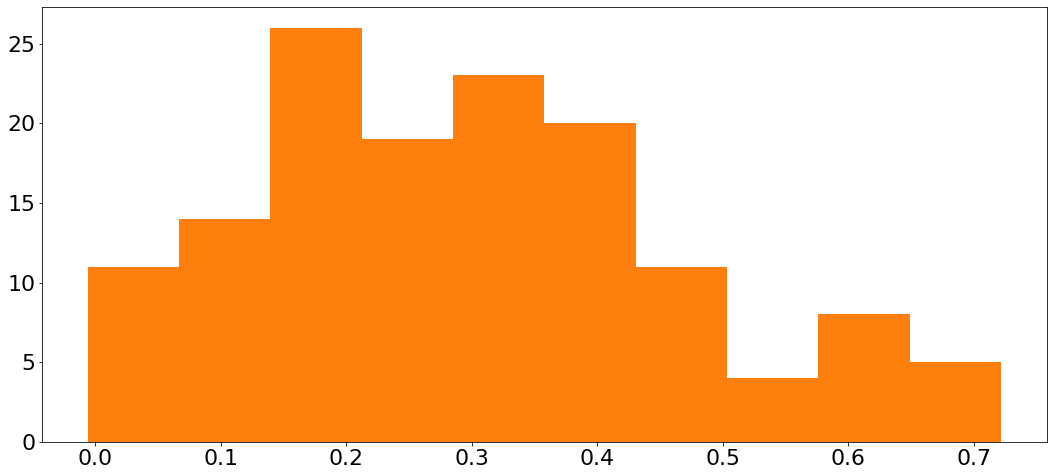

In [33]:
plt.hist(DS.target, alpha=0.5)
plt.hist(FittedModels[best_combi].predict(Features[best_combi[1]]))

for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

In [38]:
ModelName

'Kernel Ridge NM'

In [39]:
results = pd.DataFrame.from_dict(FittedModels[(ModelName, 'dataset + Projections OS BOP')].cv_results_)#[['params','mean_test_score']]

In [40]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_regressor__alpha', 'param_regressor__coef0',
       'param_regressor__degree', 'param_regressor__kernel', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

In [41]:
results.groupby('param_regressor__degree').max()['mean_test_score']

param_regressor__degree
4   -0.076430
5   -0.076113
6   -0.075879
7   -0.075694
Name: mean_test_score, dtype: float64

In [42]:
best_scores

test         train
Kernel Ridge NM dataset + Projections BOP      0.056390  1.345730e-11
                dataset + Projections sOS BOP  0.059006  1.439961e-11
                Projections sOS BOP            0.062831  3.521176e-11
                Projections BOP                0.066553  3.566762e-11
                SOAP_specific                  0.069363  1.343549e-10
                dataset + Projections OS BOP   0.075694  2.236308e-11
                Projections OS BOP             0.081301  4.494498e-11
                dataset + Canonical BOP        0.082578  6.867591e-09
                Canonical BOP                  0.100805  2.104959e-04
                dataset                        0.103078  2.359523e-10
                SOAP_canonicalFe               0.180664  4.494297e-02
                SOAP_canonicalW                0.180664  4.494297e-02
                atomic                         0.187162  3.845790e-02
                Pyscal                         0.188684  1.123495e-01

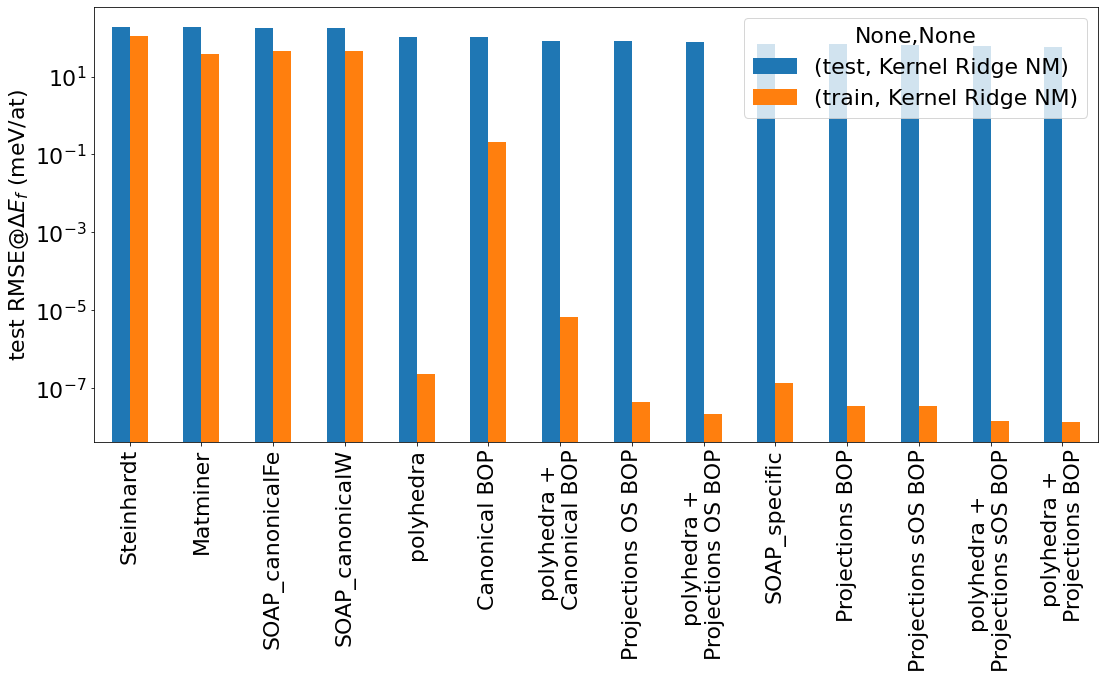

In [43]:
ax = plot_best_scores(best_scores, ModelName=ModelName)

# Recursivity

In [39]:
Tester = DatasetTester()

In [40]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [41]:
import copy

In [42]:
RecursivityModels = copy.deepcopy(FittedModels)

In [43]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

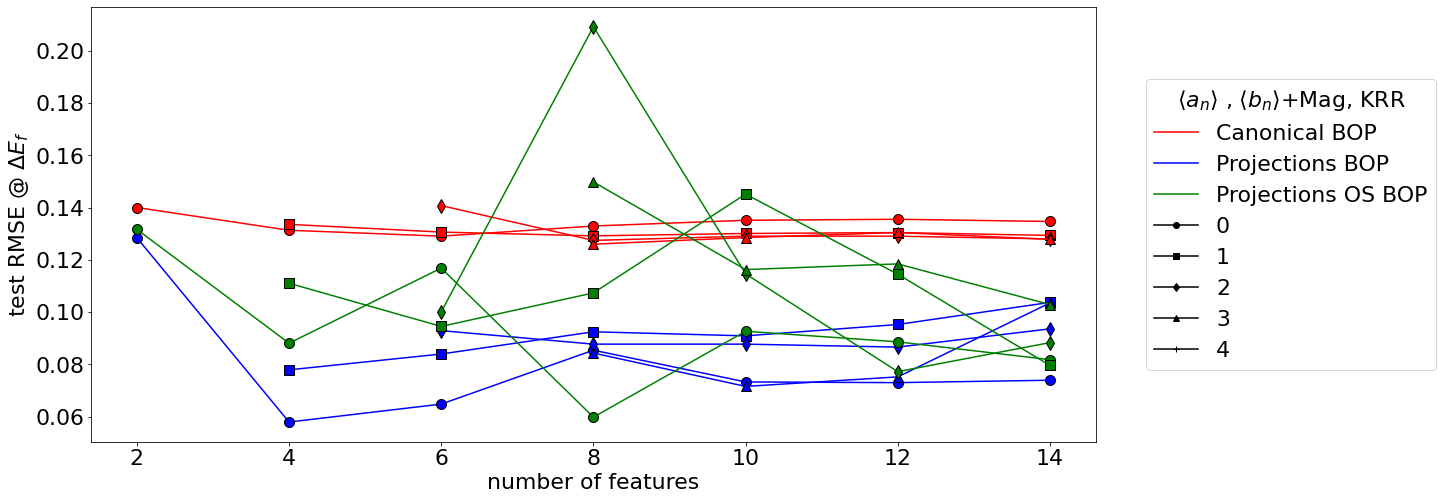

In [44]:
Tester.plot_recursivity_curve(test_scores, ModelName, )

In [45]:
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{ModelName}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [46]:
ReducedFittedModels = {}

In [47]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, 'ReducedFeaturesCVSearch.pkl')

In [48]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [49]:
MO.modeloptions

{'Kernel Ridge FM': {'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
  'regressor__kernel': ['rbf', 'polynomial'],
  'regressor__degree': [4, 5, 6, 7],
  'regressor__coef0': [0, 1, 10]}}

In [50]:
maxorders = [8,10,12,14,16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  #maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/110 [00:00<?, ?it/s]

In [51]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [52]:
somecombi = (ModelName, 'Projections BOP')

In [53]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [54]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [55]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [56]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [57]:
model = best_scores_reduced.index.get_level_values(0)

In [58]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [59]:
test_scores_vs_max[ModelName]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.060568,0.060236,0.058331,0.057383,0.063679,0.060155
10,0.047647,0.065659,0.048390,0.051208,0.066582,0.050729
12,0.054100,0.070734,0.052447,0.049686,0.069210,0.048171
14,0.054194,0.071535,0.058749,0.051357,0.070489,0.054518
16,0.065638,0.068793,0.066519,0.065774,0.068437,0.066369


In [60]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


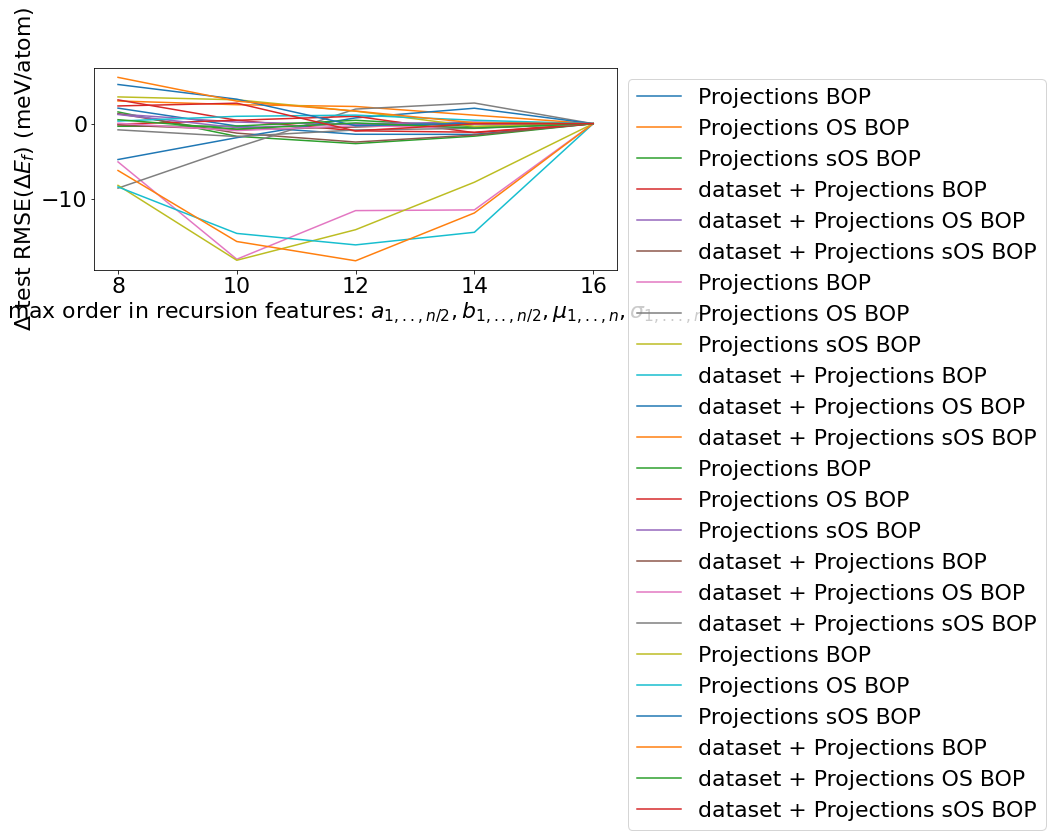

In [61]:
fig, ax = plt.subplots(figsize=(15,8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values -test_scores_vs_max[combi].values[-1])*1000 #- full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index,drmse , label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1,1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity.eps'))

# Feature Concatenation 

In [64]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().NewFeatureConcatenate
#from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate

In [65]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', 'concatenation_results.pkl')
if os.path.exists(feature_concat_resul_loc):
    with open (feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)

In [67]:
print(key) in keyFCresults.keys()

dict_keys([('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'Projections BOP'), ('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset + Projections BOP'), ('Kernel Ridge', 'dataset + Projections OS BOP'), ('Kernel Ridge', 'Pyscal'), ('Kernel Ridge', 'Projections sOS BOP'), ('Kernel Ridge', 'dataset + Canonical BOP'), ('Kernel Ridge', 'dataset + Projections sOS BOP'), ('MLP', 'atomic'), ('MLP', 'dataset'), ('MLP', 'Pyscal'), ('MLP', 'Canonical BOP'), ('MLP', 'Projections BOP'), ('MLP', 'Projections OS BOP'), ('MLP', 'Projections sOS BOP'), ('MLP', 'dataset + Canonical BOP'), ('Random Forest', 'dataset'), ('Random Forest', 'Canonical BOP'), ('Random Forest', 'Projections BOP'), ('Random Forest', 'Projections OS BOP'), ('Random Forest', 'Projections sOS BOP'), ('Random Forest', 'dataset + Canonical BOP'), ('Random Forest', 'dataset + Projections BOP'), ('Random Forest', 'dataset + Projections OS BOP'), ('Random Forest', 'dataset + Projections sOS BOP'), ('M

In [ ]:
%capture output
for combi, fmodel in FittedModels.items(): # DS.Features.keys(): #['Canonical BOP']:
    if ModelName not in combi:
        continue
    model = copy.deepcopy(fmodel.best_estimator_)
    if combi in FCresults.keys():
        continue
    FC =  FeatureConcatenate(DS, model, fmodel.best_params_,)
    FCresults[combi] = FC.get_best_features_list(combi[1], num_features = DS.Features[combi[1]].shape[1])
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

In [ ]:
%

In [ ]:
FCresults[(f'Kernel Ridge {MagneticCase}','Projections BOP')].test.min()

In [ ]:
FCresults[(f'Kernel Ridge {MagneticCase}','Projections OS BOP')].test.min()

In [ ]:
FCresults[(f'Kernel Ridge {MagneticCase}','Projections sOS BOP')].test.min()

In [ ]:
FCresults.keys()

In [ ]:
FCresults[('Kernel Ridge','SOAP_specific_4_8_6_0.1_rbf_gto')].test.min()

In [ ]:
FCresults[('Kernel Ridge','SOAP_canonical_4_8_6_0.1_rbf_gto')].test.min()

In [ ]:
from Tools.DatasetTools.Tools import get_str_formatted

In [ ]:
FCresults.keys()

In [ ]:
#iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
iwanttoplot = ['atomic', 'SOAP_canonical_4_8_6_0.1_rbf_gto','SOAP_specific_4_8_6_0.1_rbf_gto', 'dataset', 'Canonical BOP', 'Projections OS BOP']#, 'Projections sOS BOP' ]

In [ ]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [ ]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [ ]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(figsize=(13,10))
for combi, result in FCresults.items():
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result.shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')
    y = result['test']*1000
    axes.plot(x, y ,'o',c=colors[combi[1]], label=legend)
    axes.text(x[-1], y[-1], legend, horizontalalignment='right')
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
fig.suptitle(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves.eps')

selected_pos = FCresults[(ModelName, 'Projections sOS BOP')].index[0]
y_pos = FCresults[(ModelName, 'Projections sOS BOP')]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[(ModelName, 'Projections sOS BOP')].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-40), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated.eps')
axes.set_yscale('log')

## selections

In [ ]:
FCresults[(ModelName, 'Projections sOS BOP')].iloc[:20].index

In [ ]:
mask = FCresults[(ModelName, 'Projections sOS BOP')].index.str.contains('Structure')

In [81]:
FCresults[(ModelName, 'Projections sOS BOP')].loc[mask]

,test,train
Structure,0.030859,0.013503


In [76]:
Features['SOAP_4_9_6_0.1_rbf_gto']

,Structure,Mag,SOAP_1_0,SOAP_1_CN12,SOAP_1_CN14,SOAP_2_0,SOAP_2_CN12,SOAP_2_CN13,SOAP_2_CN14,SOAP_2_CN15,...,SOAP_1190_CN12,SOAP_1193_0,SOAP_1193_CN12,SOAP_1194_0,SOAP_1195_0,SOAP_1195_CN12,SOAP_1196_0,SOAP_1196_CN12,SOAP_1196_CN14,random
Fe_pv14Mo_sv10.C36-AABAB.FM,3,0,-0.001472,-0.000621,0.000000,0.005436,0.002294,0.000000,0.000000,0.000000e+00,...,0.000005,-0.000562,-0.000556,0.000101,-0.000030,0.000058,0.000734,0.000652,0.000000,0.189603
Fe_pv22Mo_sv8.sigma-AAAAB.FM,10,0,-0.001829,-0.000828,-0.000665,0.006809,0.003084,0.000000,0.002474,1.251363e-03,...,0.000178,-0.000229,-0.000167,0.000209,-0.000204,-0.000120,0.000433,0.000234,0.000165,0.749568
Fe_pv14Mo_sv10.C36-ABAAB.FM,3,0,-0.001452,-0.001025,0.000000,0.005357,0.003770,0.000000,0.000000,0.000000e+00,...,0.000245,-0.000428,-0.000437,0.000416,-0.000477,-0.000310,0.000961,0.000814,0.000000,0.032052
Fe_pv18Mo_sv12.sigma-ABBAA.FM,10,0,-0.001491,-0.000830,-0.000662,0.005530,0.003082,0.000000,0.002448,7.246226e-09,...,0.000234,-0.000298,-0.000193,0.000314,-0.000408,-0.000198,0.000650,0.000329,0.000263,0.551632
Fe_pv26Mo_sv4.sigma-ABAAA.FM,10,0,-0.002161,-0.000822,-0.001339,0.008069,0.003076,0.000000,0.004992,1.618328e-09,...,0.000069,-0.000057,-0.000036,0.000095,-0.000102,-0.000068,0.000140,0.000085,0.000045,0.238758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv24Mo_sv5.chi-BBAA.NM,6,1,-0.002060,-0.001022,0.000000,0.007671,0.003776,0.003895,0.000000,0.000000e+00,...,0.000114,-0.000039,-0.000023,0.000223,-0.000220,-0.000161,0.000232,0.000161,0.000000,0.921505
Fe_pv4Mo_sv2.C15-A2B.NM,2,1,-0.001620,-0.000810,0.000000,0.005922,0.002961,0.000000,0.000000,0.000000e+00,...,0.000253,-0.000015,0.000010,0.000850,-0.000767,-0.000430,0.000699,0.000382,0.000000,0.842395
Fe_pv25Mo_sv4.chi-ABAA.NM,6,1,-0.002149,-0.001023,0.000000,0.008007,0.003785,0.003893,0.000000,0.000000e+00,...,0.000069,-0.000032,-0.000014,0.000152,-0.000152,-0.000099,0.000166,0.000099,0.000000,0.151581
Fe_pv16Mo_sv8.C36-BBAAA.NM,3,1,-0.001621,-0.001621,0.000000,0.005927,0.005927,0.000000,0.000000,0.000000e+00,...,0.000451,-0.000020,-0.000053,0.000822,-0.000745,-0.000653,0.000683,0.000617,0.000000,0.570853


# Final learn after feature selection 

In [129]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'Projections BOP'), ('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset + Projections BOP'), ('Kernel Ridge', 'dataset + Projections OS BOP'), ('Kernel Ridge', 'Pyscal'), ('Kernel Ridge', 'Projections sOS BOP'), ('Kernel Ridge', 'dataset + Canonical BOP'), ('Kernel Ridge', 'dataset + Projections sOS BOP'), ('MLP', 'atomic'), ('MLP', 'dataset'), ('MLP', 'Pyscal'), ('MLP', 'Canonical BOP'), ('MLP', 'Projections BOP'), ('MLP', 'Projections OS BOP'), ('MLP', 'Projections sOS BOP'), ('MLP', 'dataset + Canonical BOP'), ('Random Forest', 'dataset'), ('Random Forest', 'Canonical BOP'), ('Random Forest', 'Projections BOP'), ('Random Forest', 'Projections OS BOP'), ('Random Forest', 'Projections sOS BOP'), ('Random Forest', 'dataset + Canonical BOP'), ('Random Forest', 'dataset + Projections BOP'), ('Random Forest', 'dataset + Projections OS BOP'), ('Random Forest', 'dataset + Projections sOS BOP'), ('M

In [130]:
OptimalFittedScores = {}
OptimalFittedModels = {}

In [131]:
Models[ModelName]

Pipeline(steps=[('scaler', StandardScaler()), ('regressor', KernelRidge())])

In [132]:
for combi in FCresults.keys():
    if ModelName not in combi:
        continue
    OptimalFittedModels[combi]  = copy.deepcopy(Models[ModelName])
    params = FittedModels[combi].best_params_
    OptimalFittedModels[combi].set_params(**params) #= GridSearchCV(amodel, MO.modeloptions[ModelName], scoring = 'neg_root_mean_squared_error',return_train_score=True)
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    if 'random' in selected:
        print(f'random selected in {combi}')
    #if 'random' in selected:
    #    selected = selected.drop('random')
    OptimalFittedModels[combi].fit(X.loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    OptimalFittedScores[combi] = score_fitted_model(OptimalFittedModels[combi], X.loc[DS.samplesplit['train']], X.loc[DS.samplesplit['test']], DS.target[DS.samplesplit['train']], DS.target[DS.samplesplit['test']] )


In [133]:
OptimalFittedScores = pd.DataFrame.from_dict(OptimalFittedScores, orient='index')#.sort_values(by='test')
OptimalFittedScores.sort_values(by='test', ascending=False, inplace=True)

In [134]:
OptimalFittedFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalModels.pkl'
with open(OptimalFittedFile, 'wb') as pkl:
    pickle.dump(OptimalFittedModels, pkl)
OptimalFittedScoresFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalScores.pkl'
with open(OptimalFittedScoresFile, 'wb') as pkl:
    pickle.dump(OptimalFittedScores, pkl)


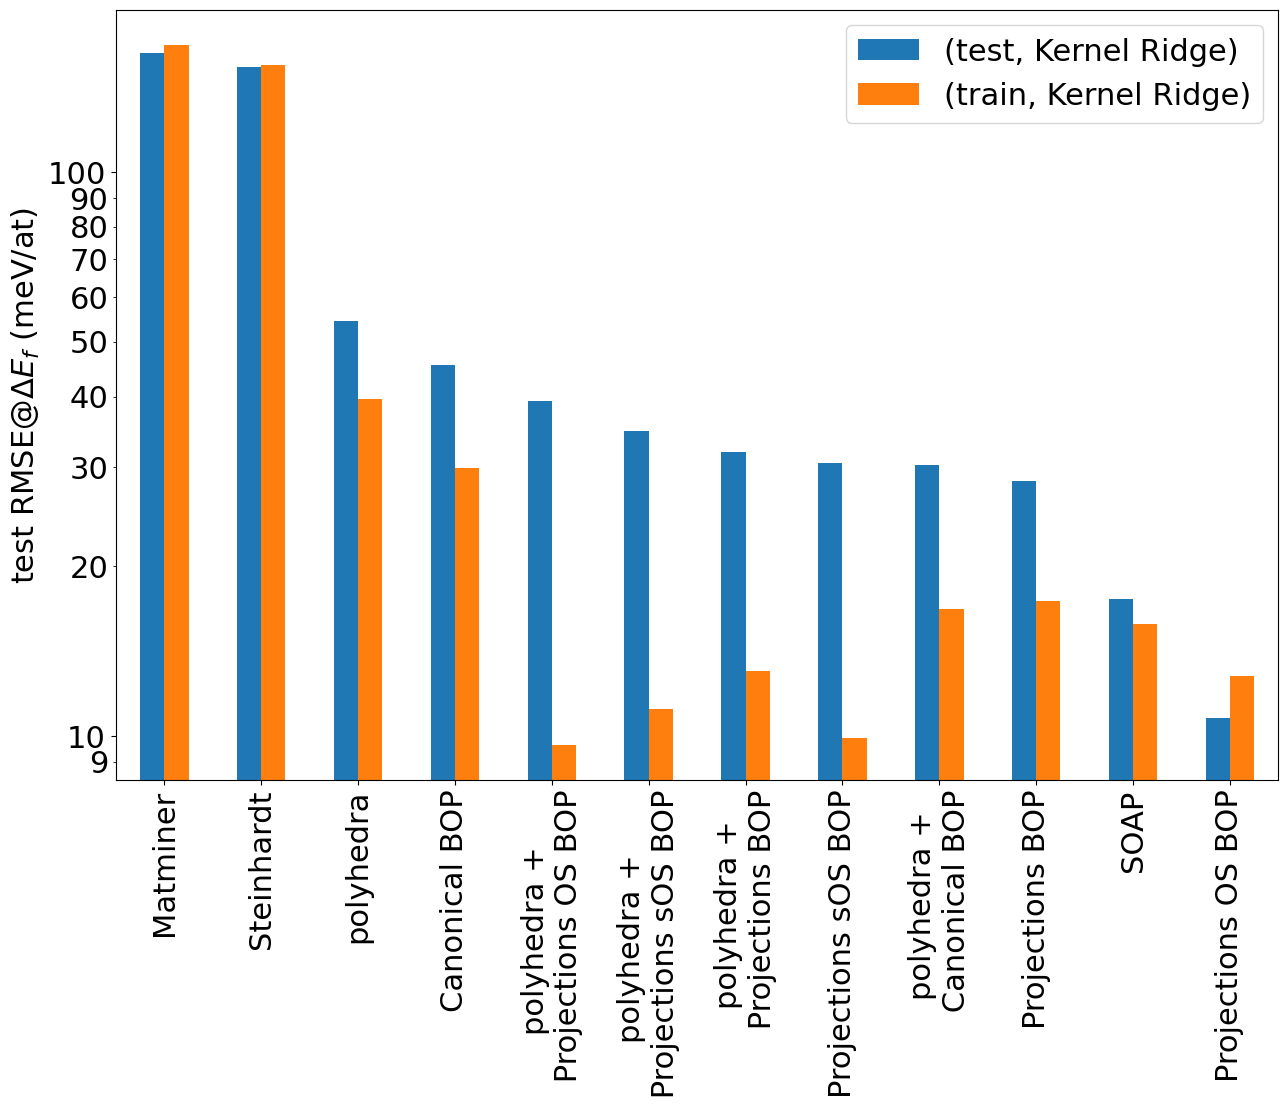

In [135]:
plot_best_scores = SourceFileLoader('plot_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().plot_best_scores

ax = plot_best_scores(OptimalFittedScores, ModelName=ModelName)
ax.tick_params(axis='y', which = 'minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.legend(title='')

# Prediction line 

In [75]:
Prediction = {}
for combi, model in OptimalFittedModels.items():
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    Prediction[combi] = model.predict(X)

In [76]:
#iwanttoplot = {'atomic':'Matminer',
#iwanttoplot = {'Canonical BOP': 'Canonical BOP', 'Projections sOS BOP':'Projections sOS BOP'}
iwanttoplot = {'dataset': 'dataset', 'Projections sOS BOP':'Projections sOS BOP'}

In [77]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


dataset dataset
Projections sOS BOP Projections sOS BOP


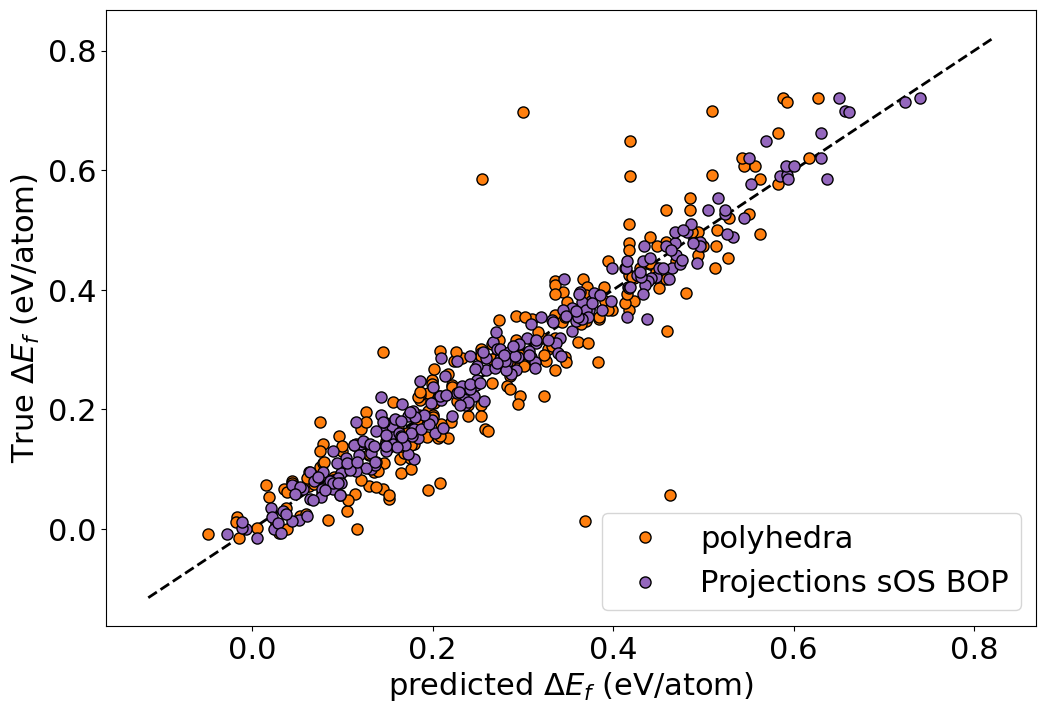

In [78]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi], DS.target, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline.eps'))

# Feature Importances 

In [79]:
importances = {}
for combi, estimator in OptimalFittedModels.items():
    print(combi[1])
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    if 'random' in selected:
        print(f'random selected in {combi}')
    X = DS.Features[combi[1]][selected]
    allimportances = get_importances(estimator , X,  DS.target)
    importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]

atomic
dataset
Pyscal
Canonical BOP
Projections BOP
random selected in ('MLP', 'Projections BOP')
Projections OS BOP
Projections sOS BOP
dataset + Canonical BOP
dataset + Projections BOP
dataset + Projections OS BOP
dataset + Projections sOS BOP


In [80]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

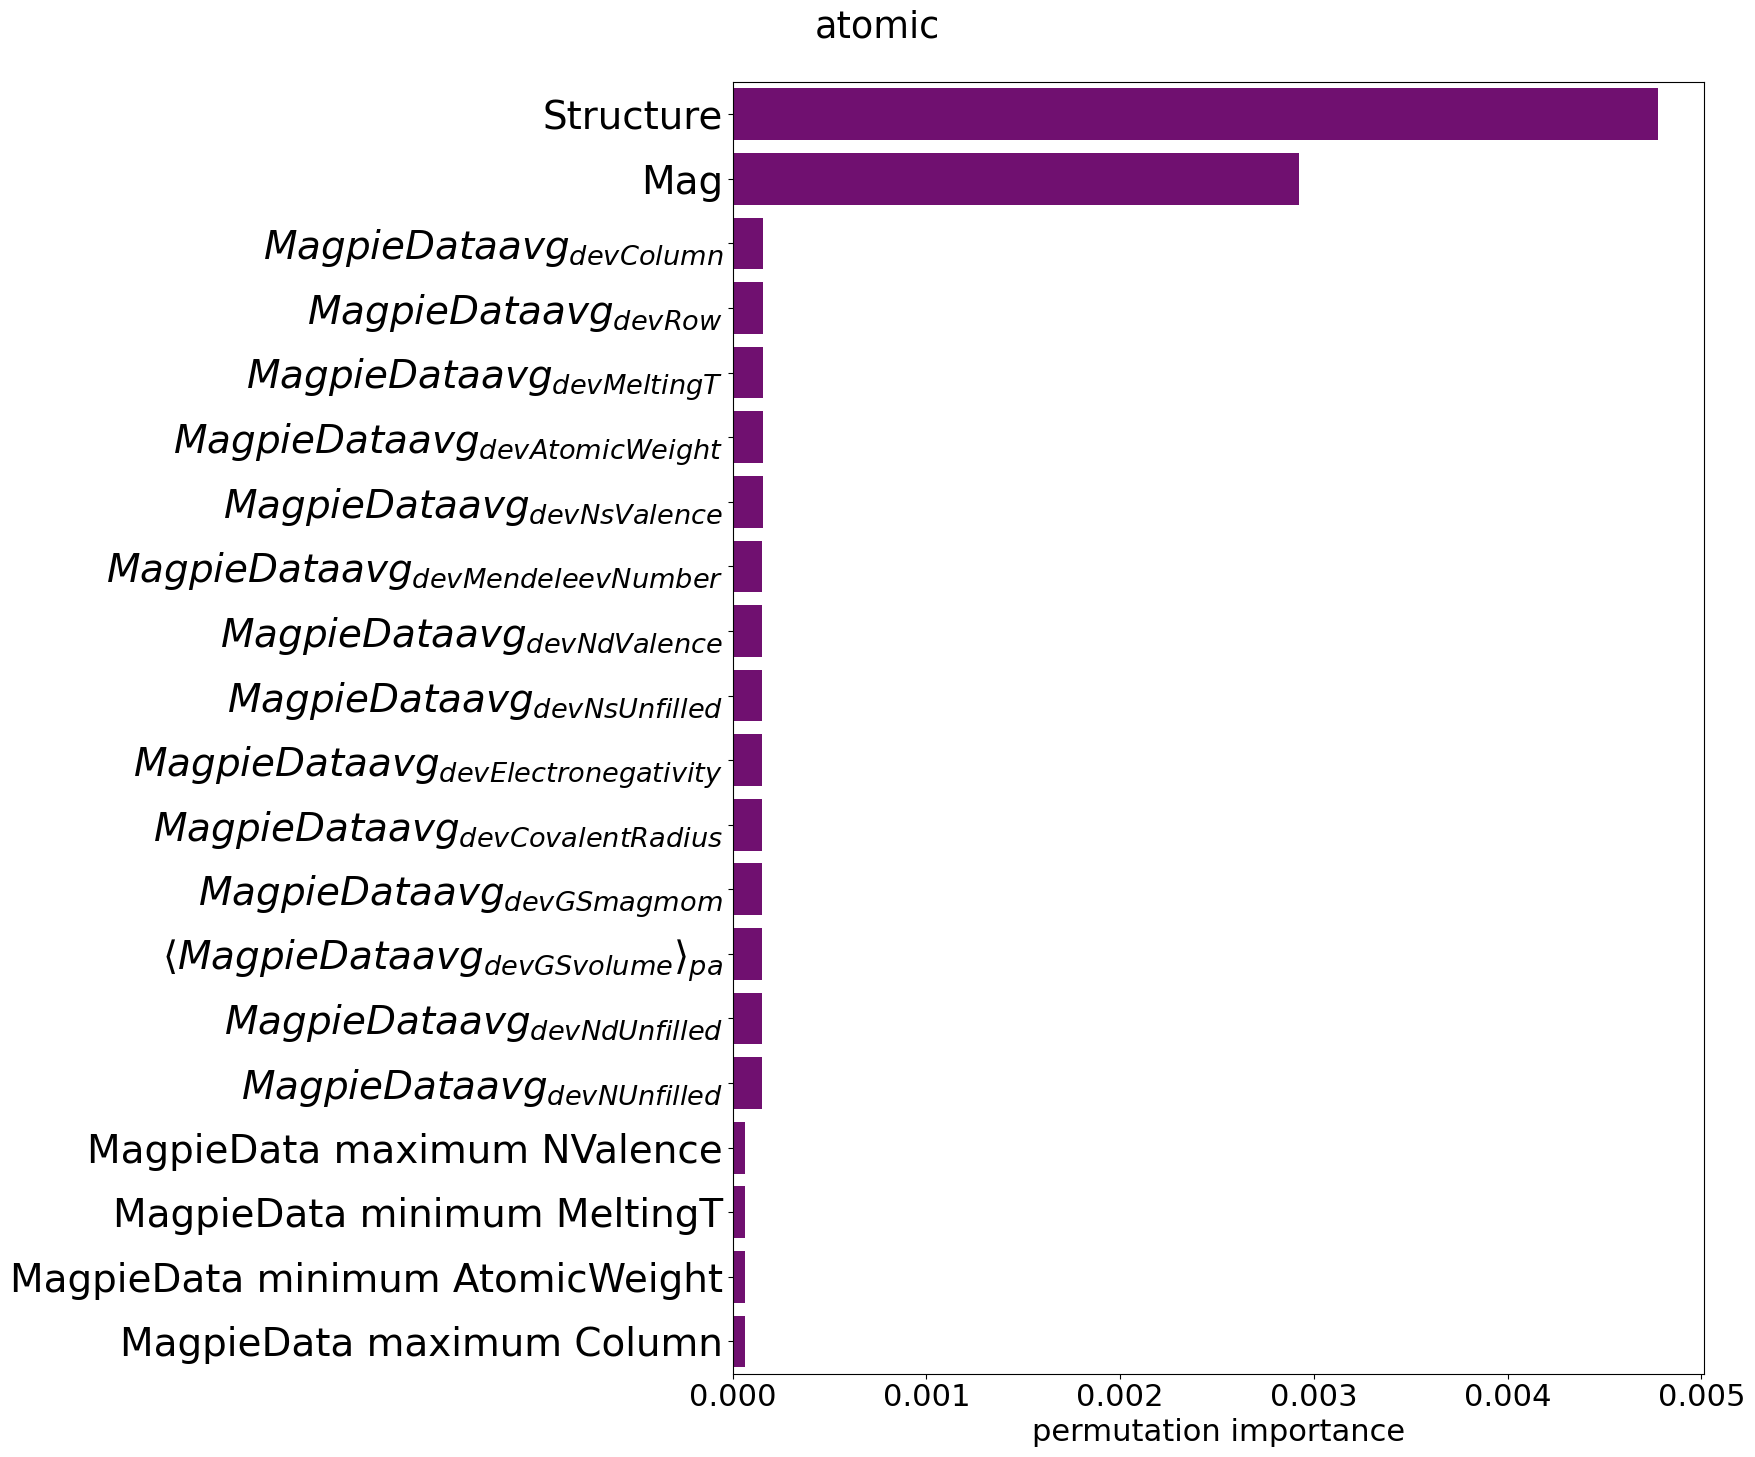

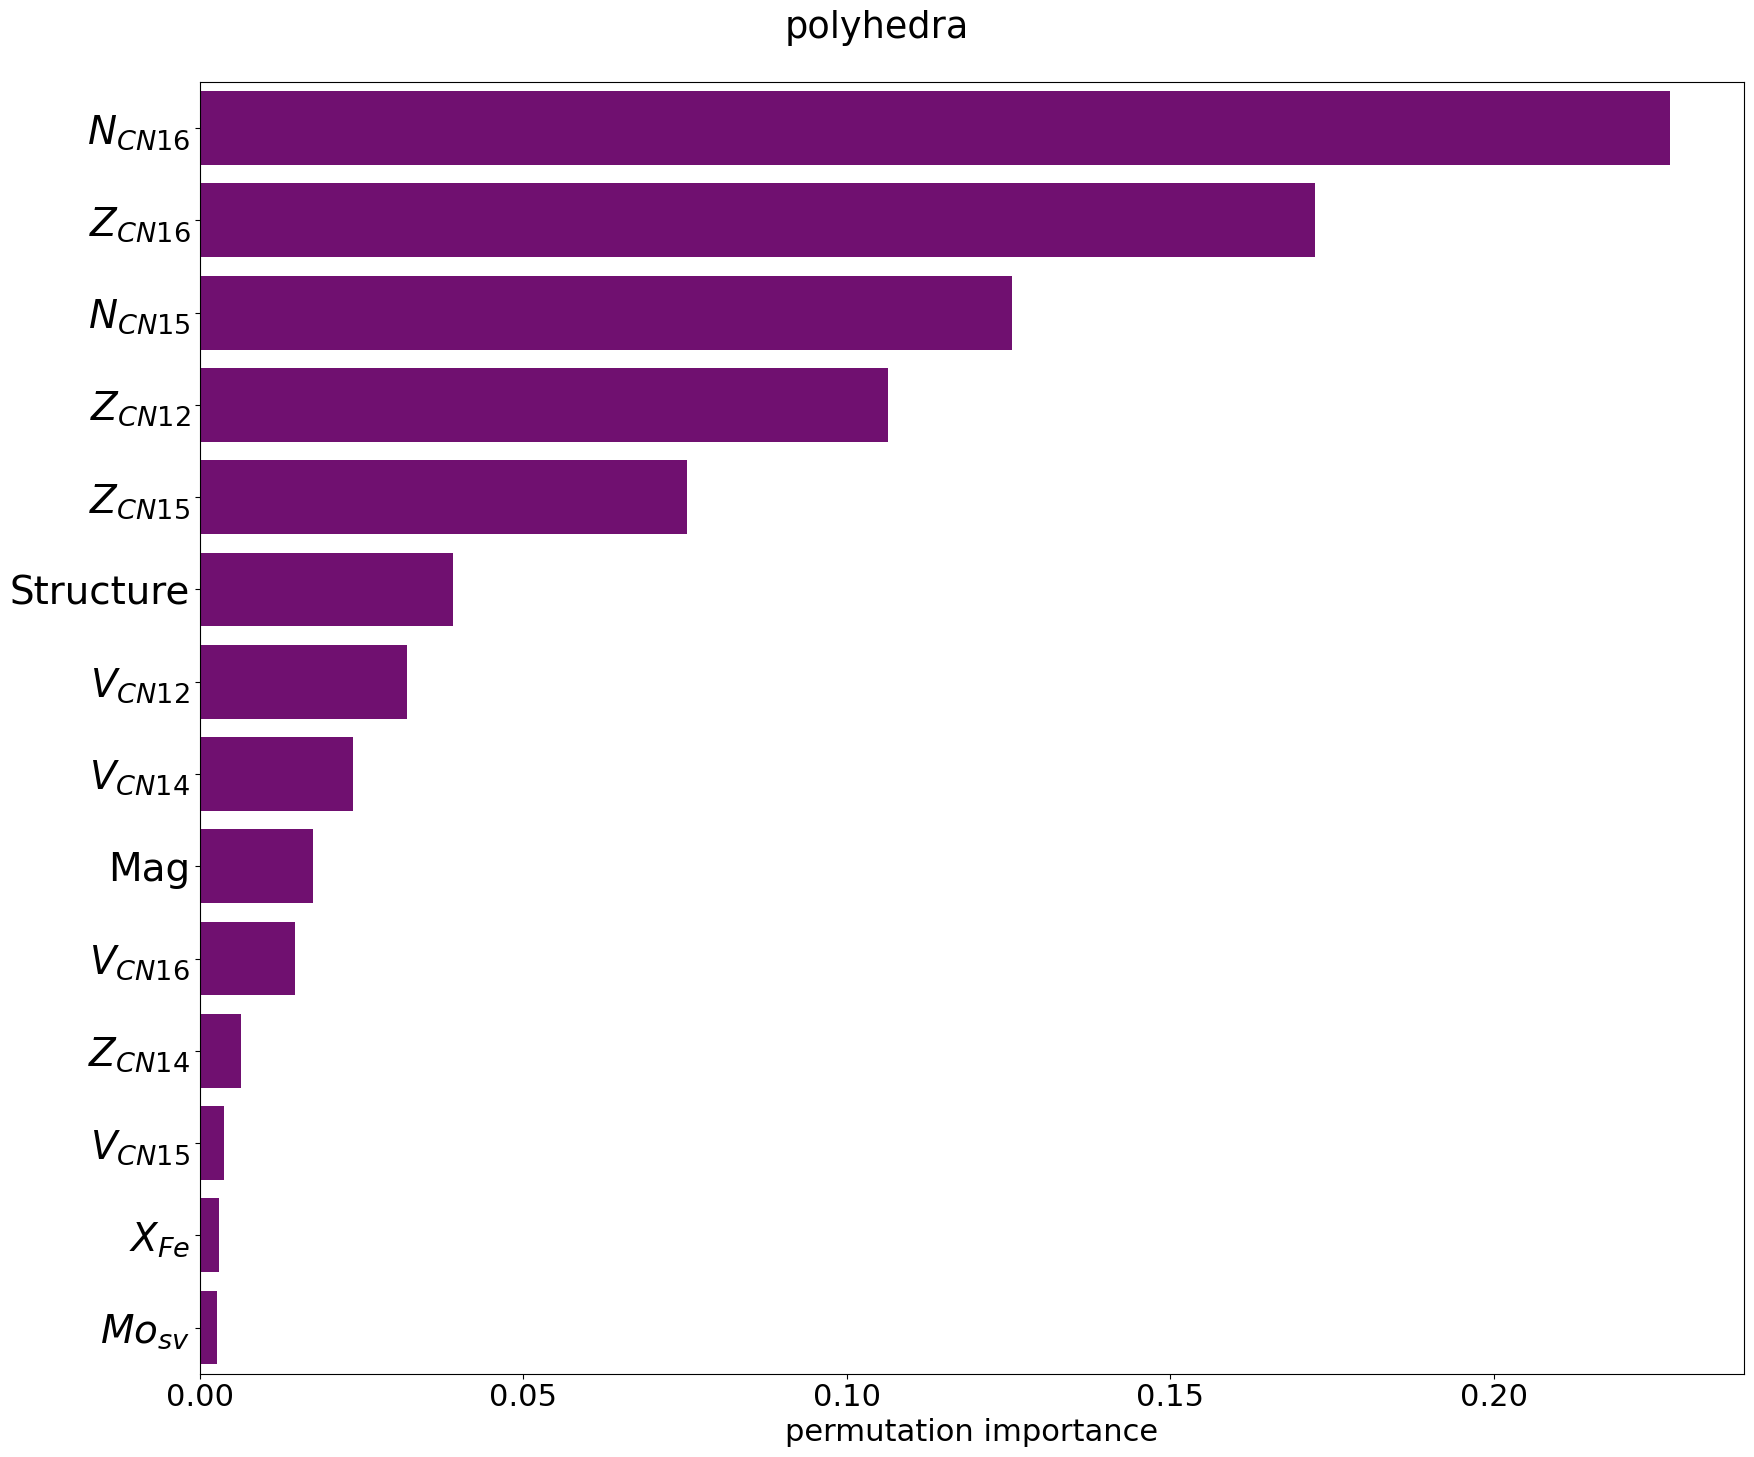

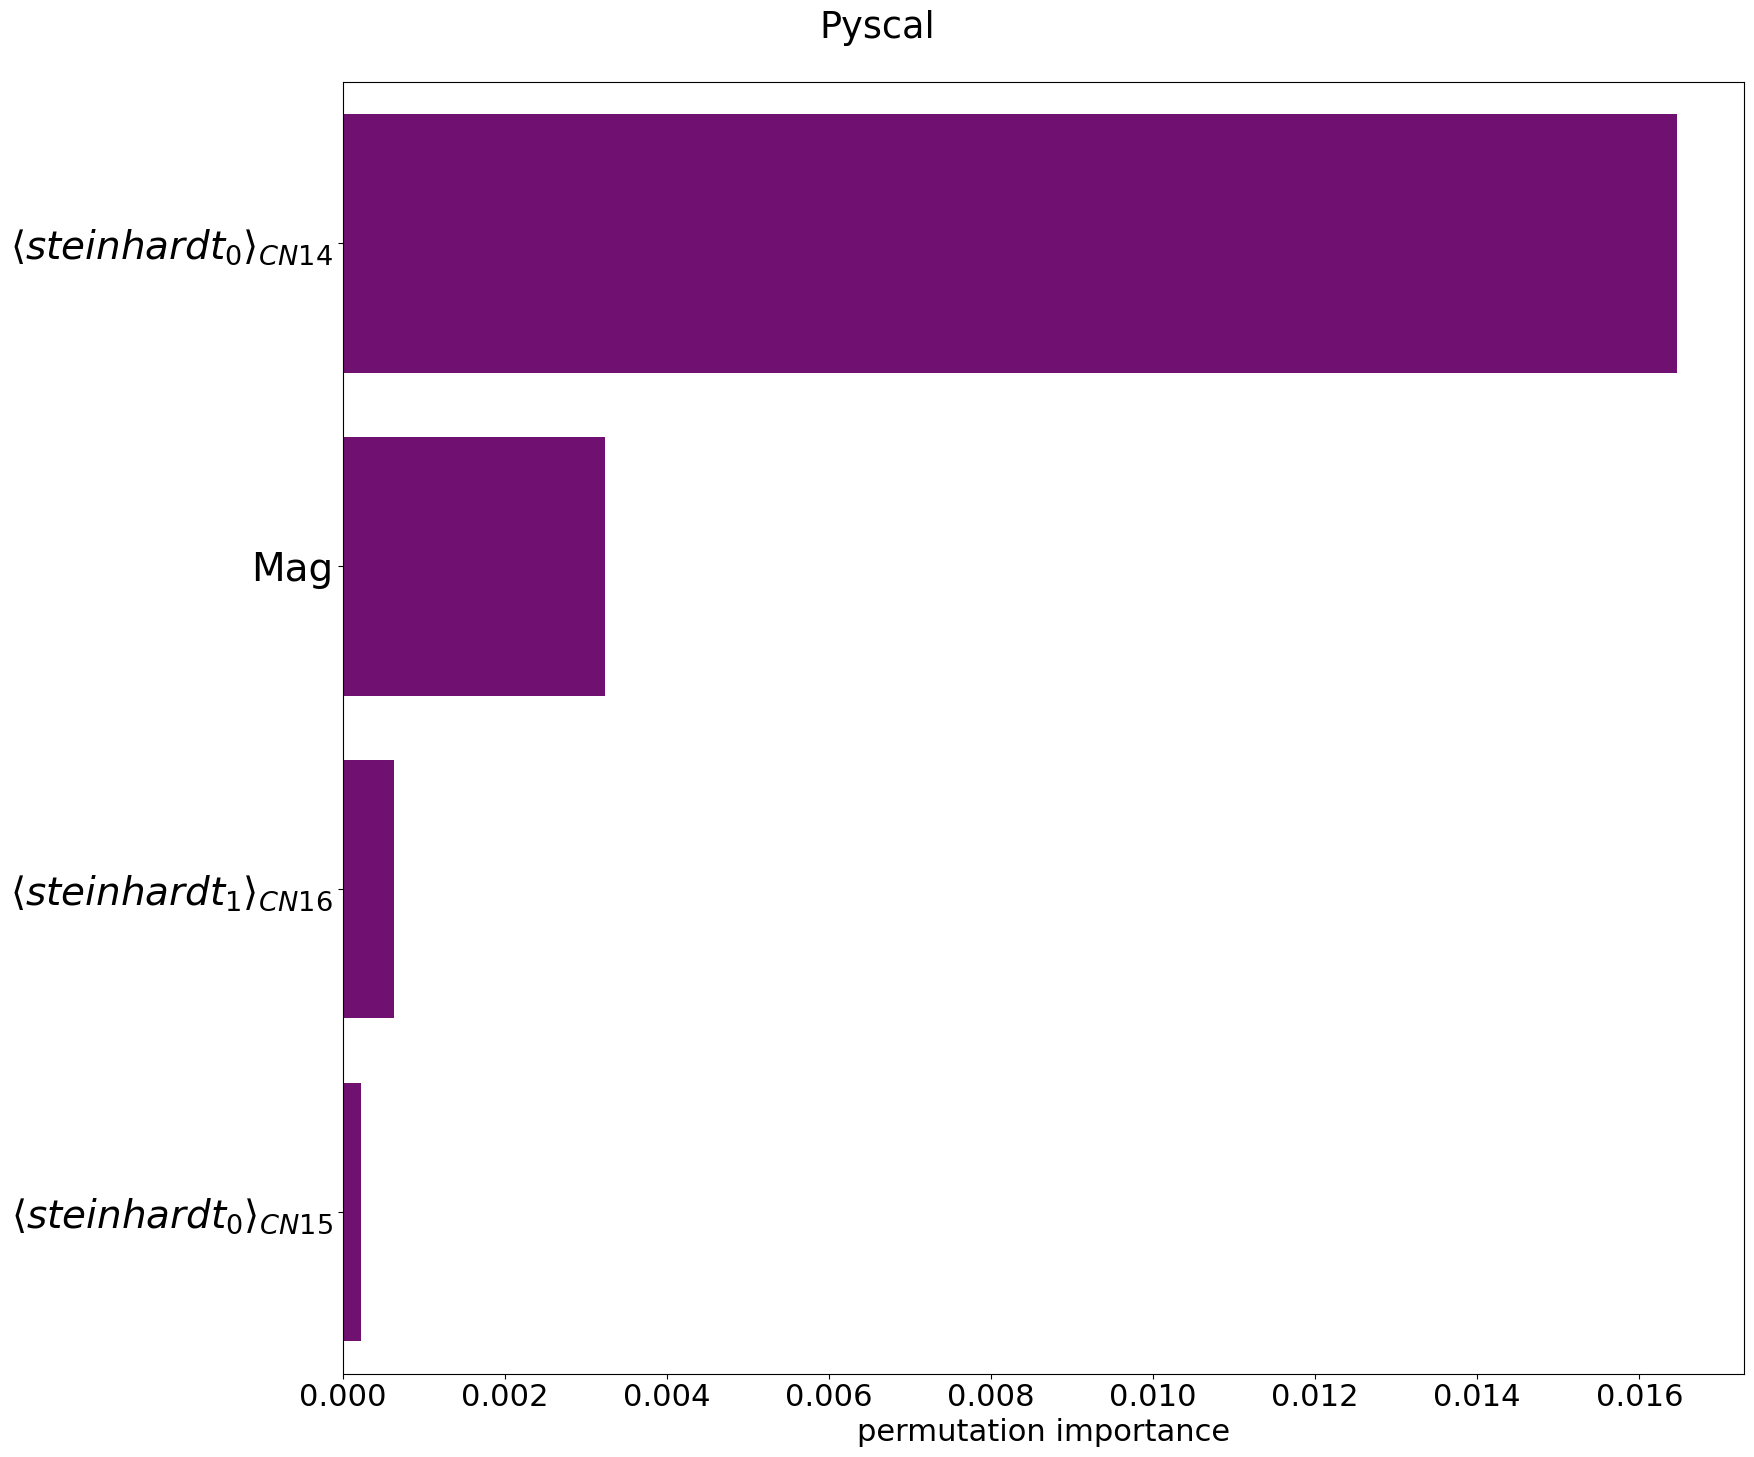

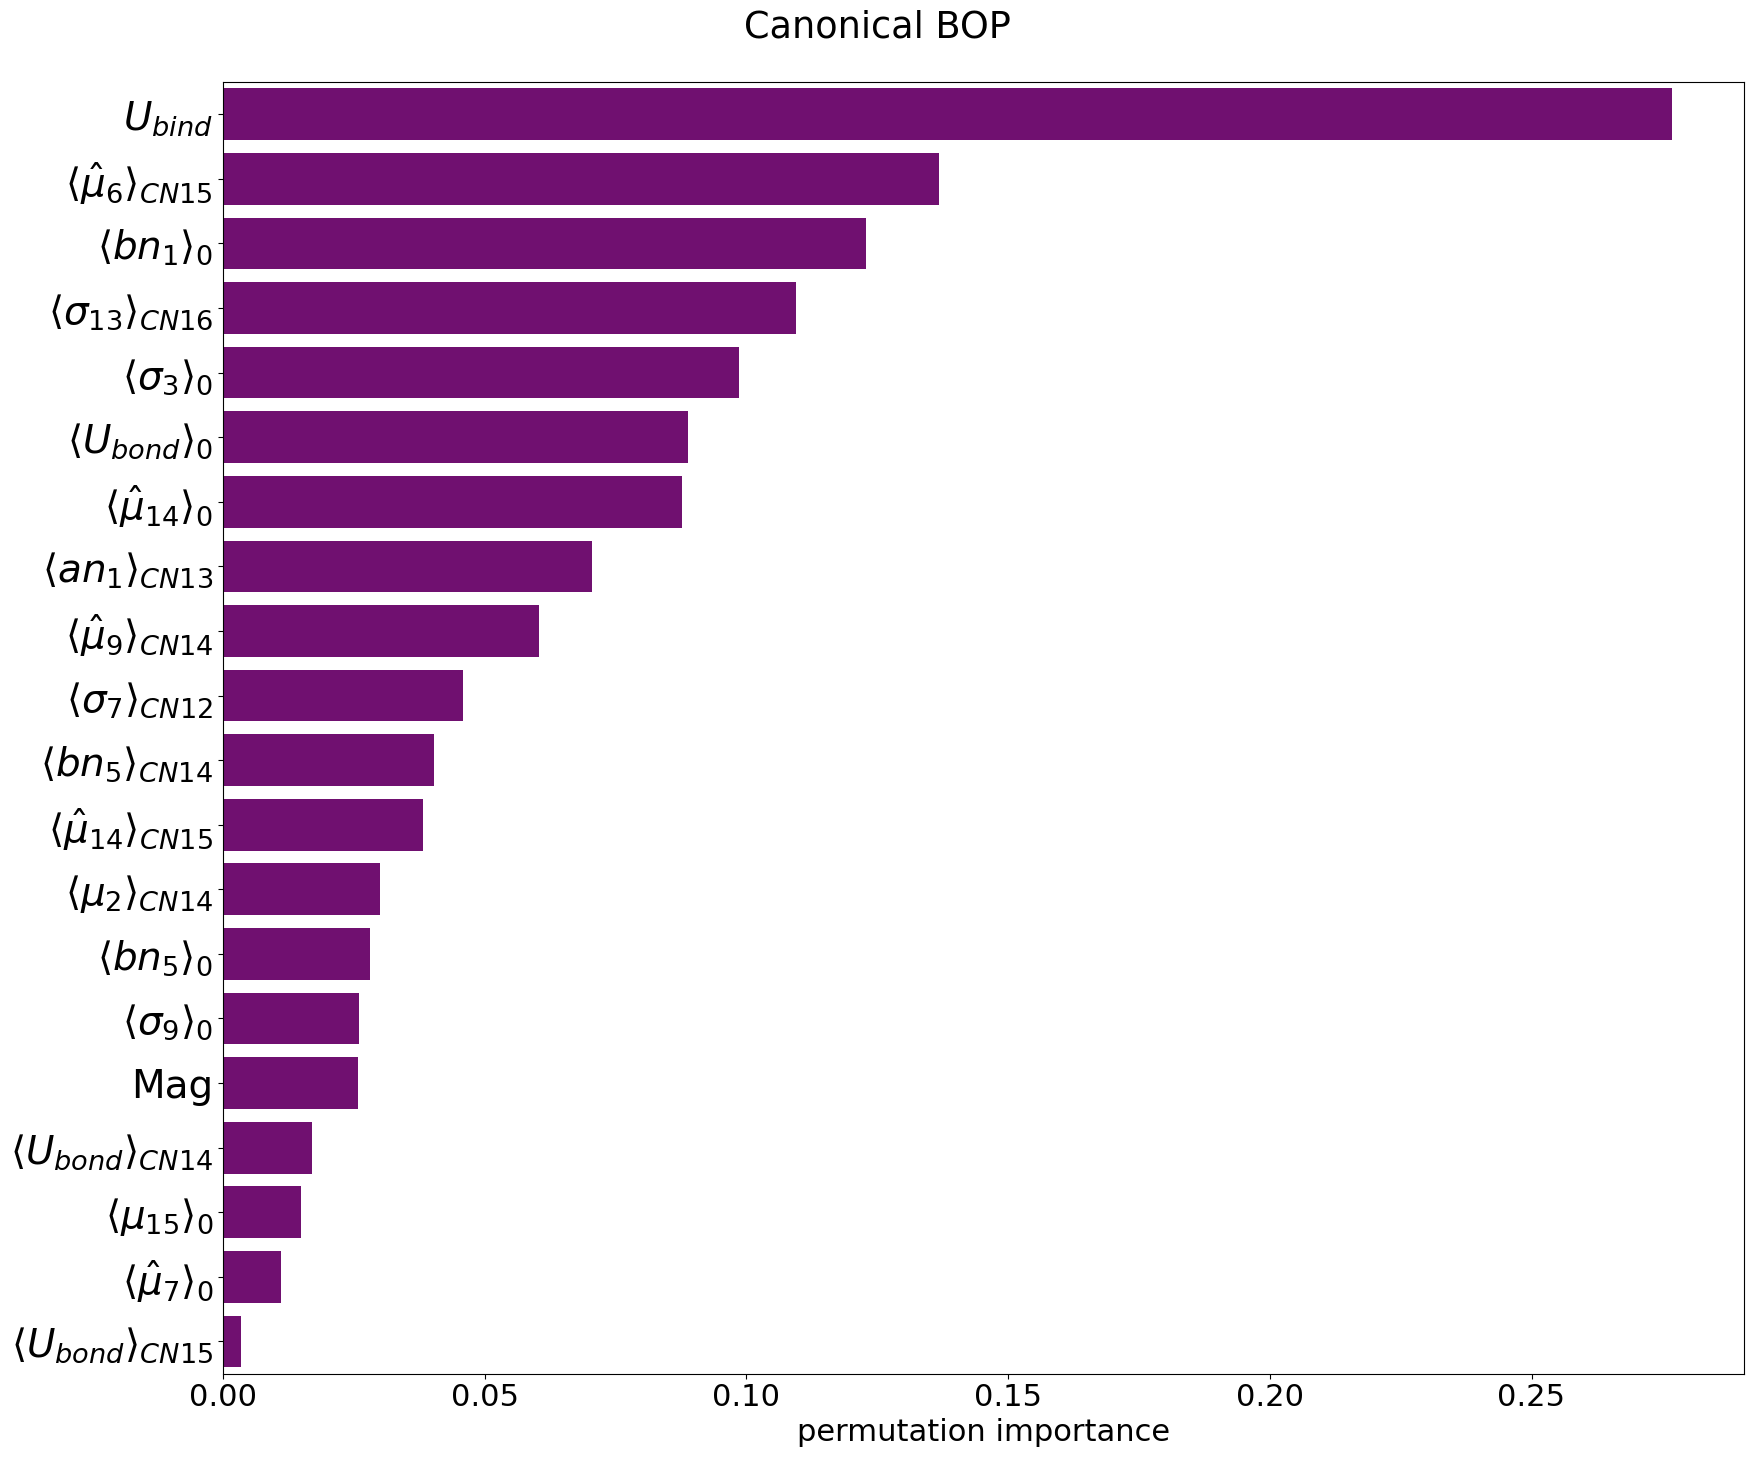

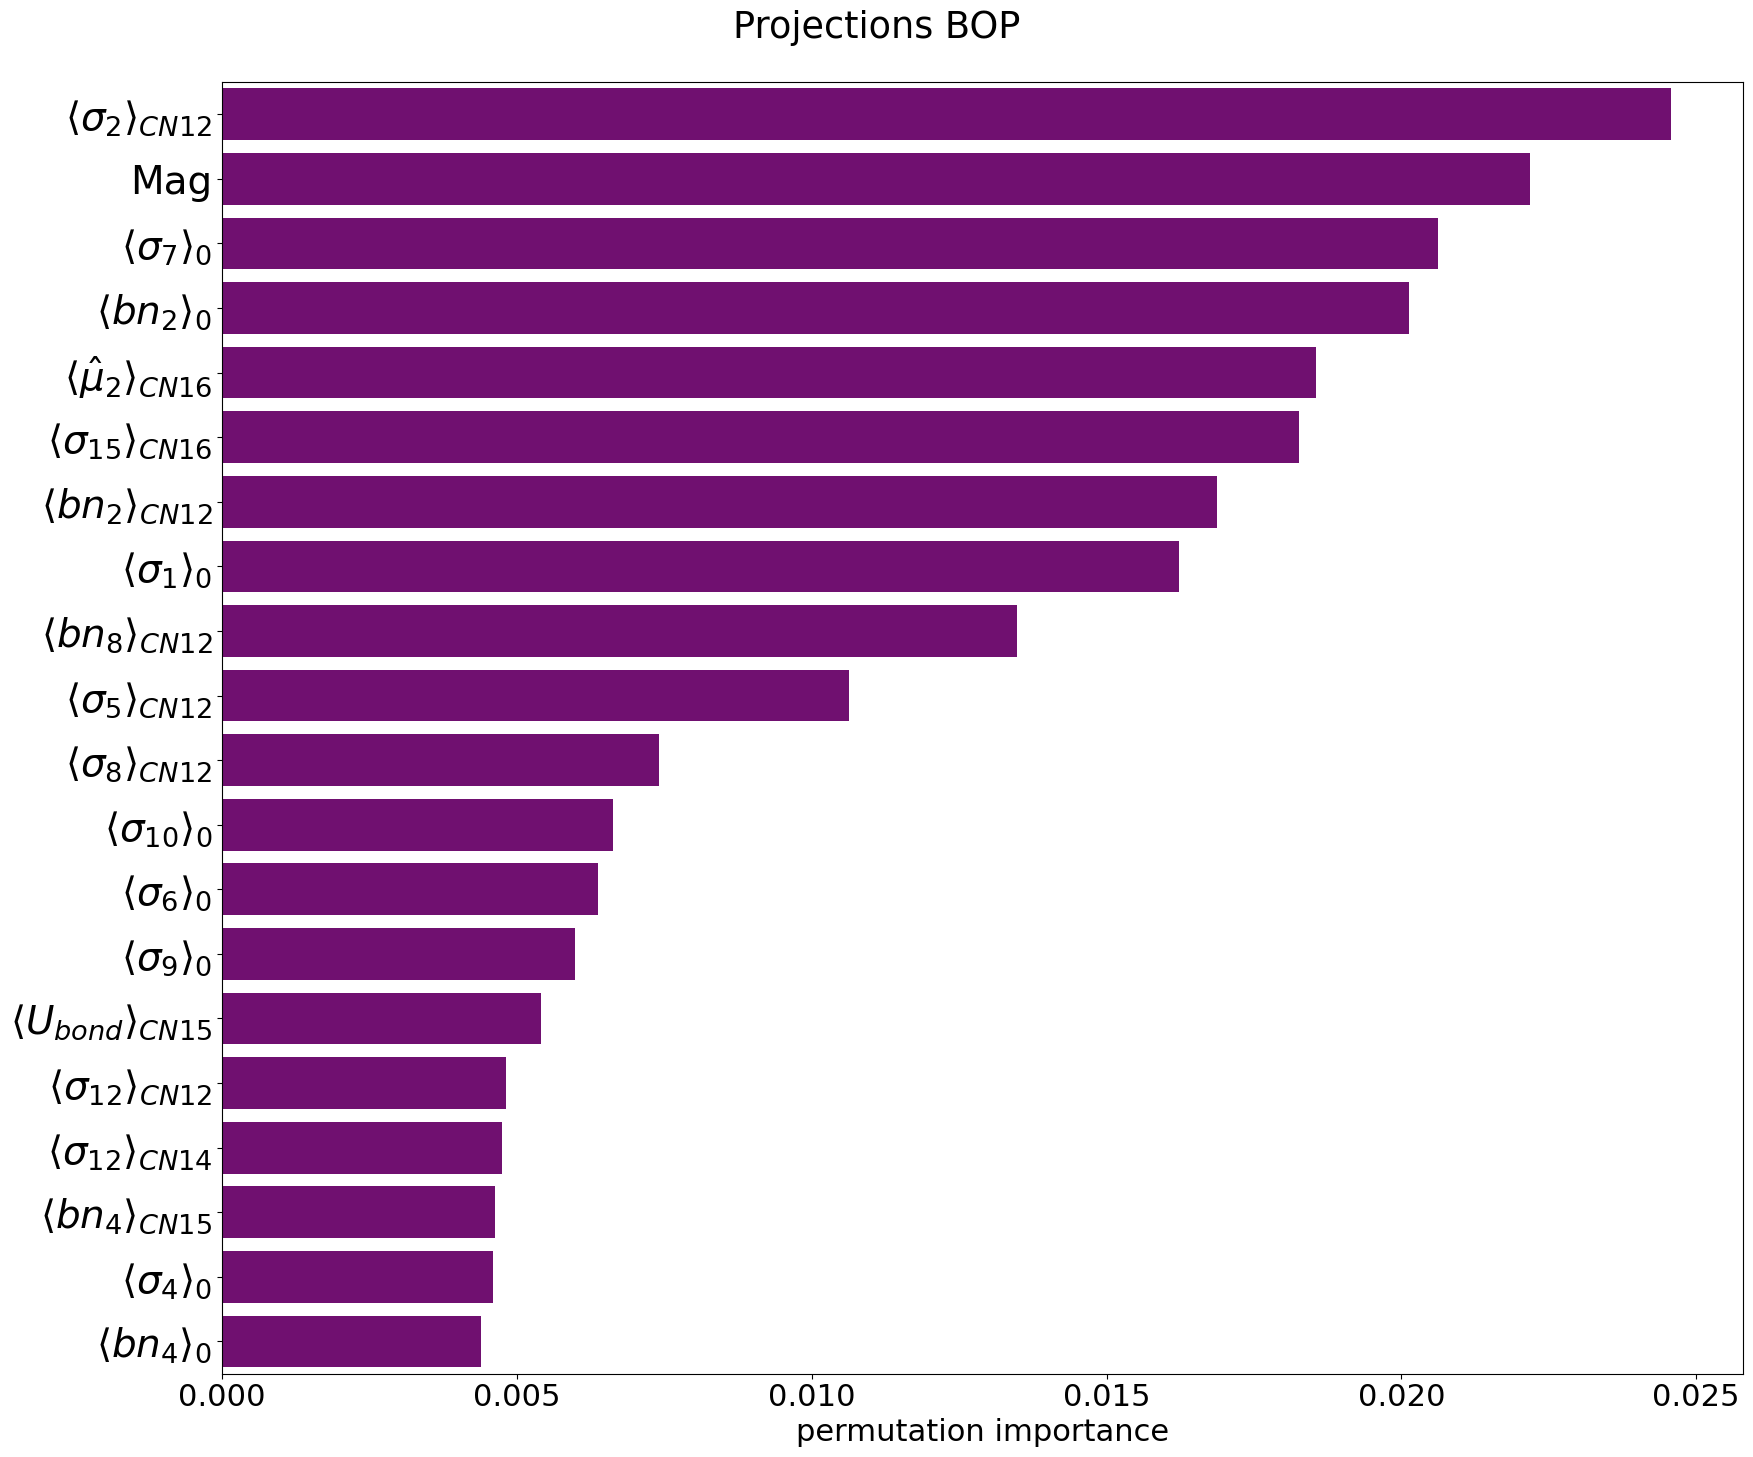

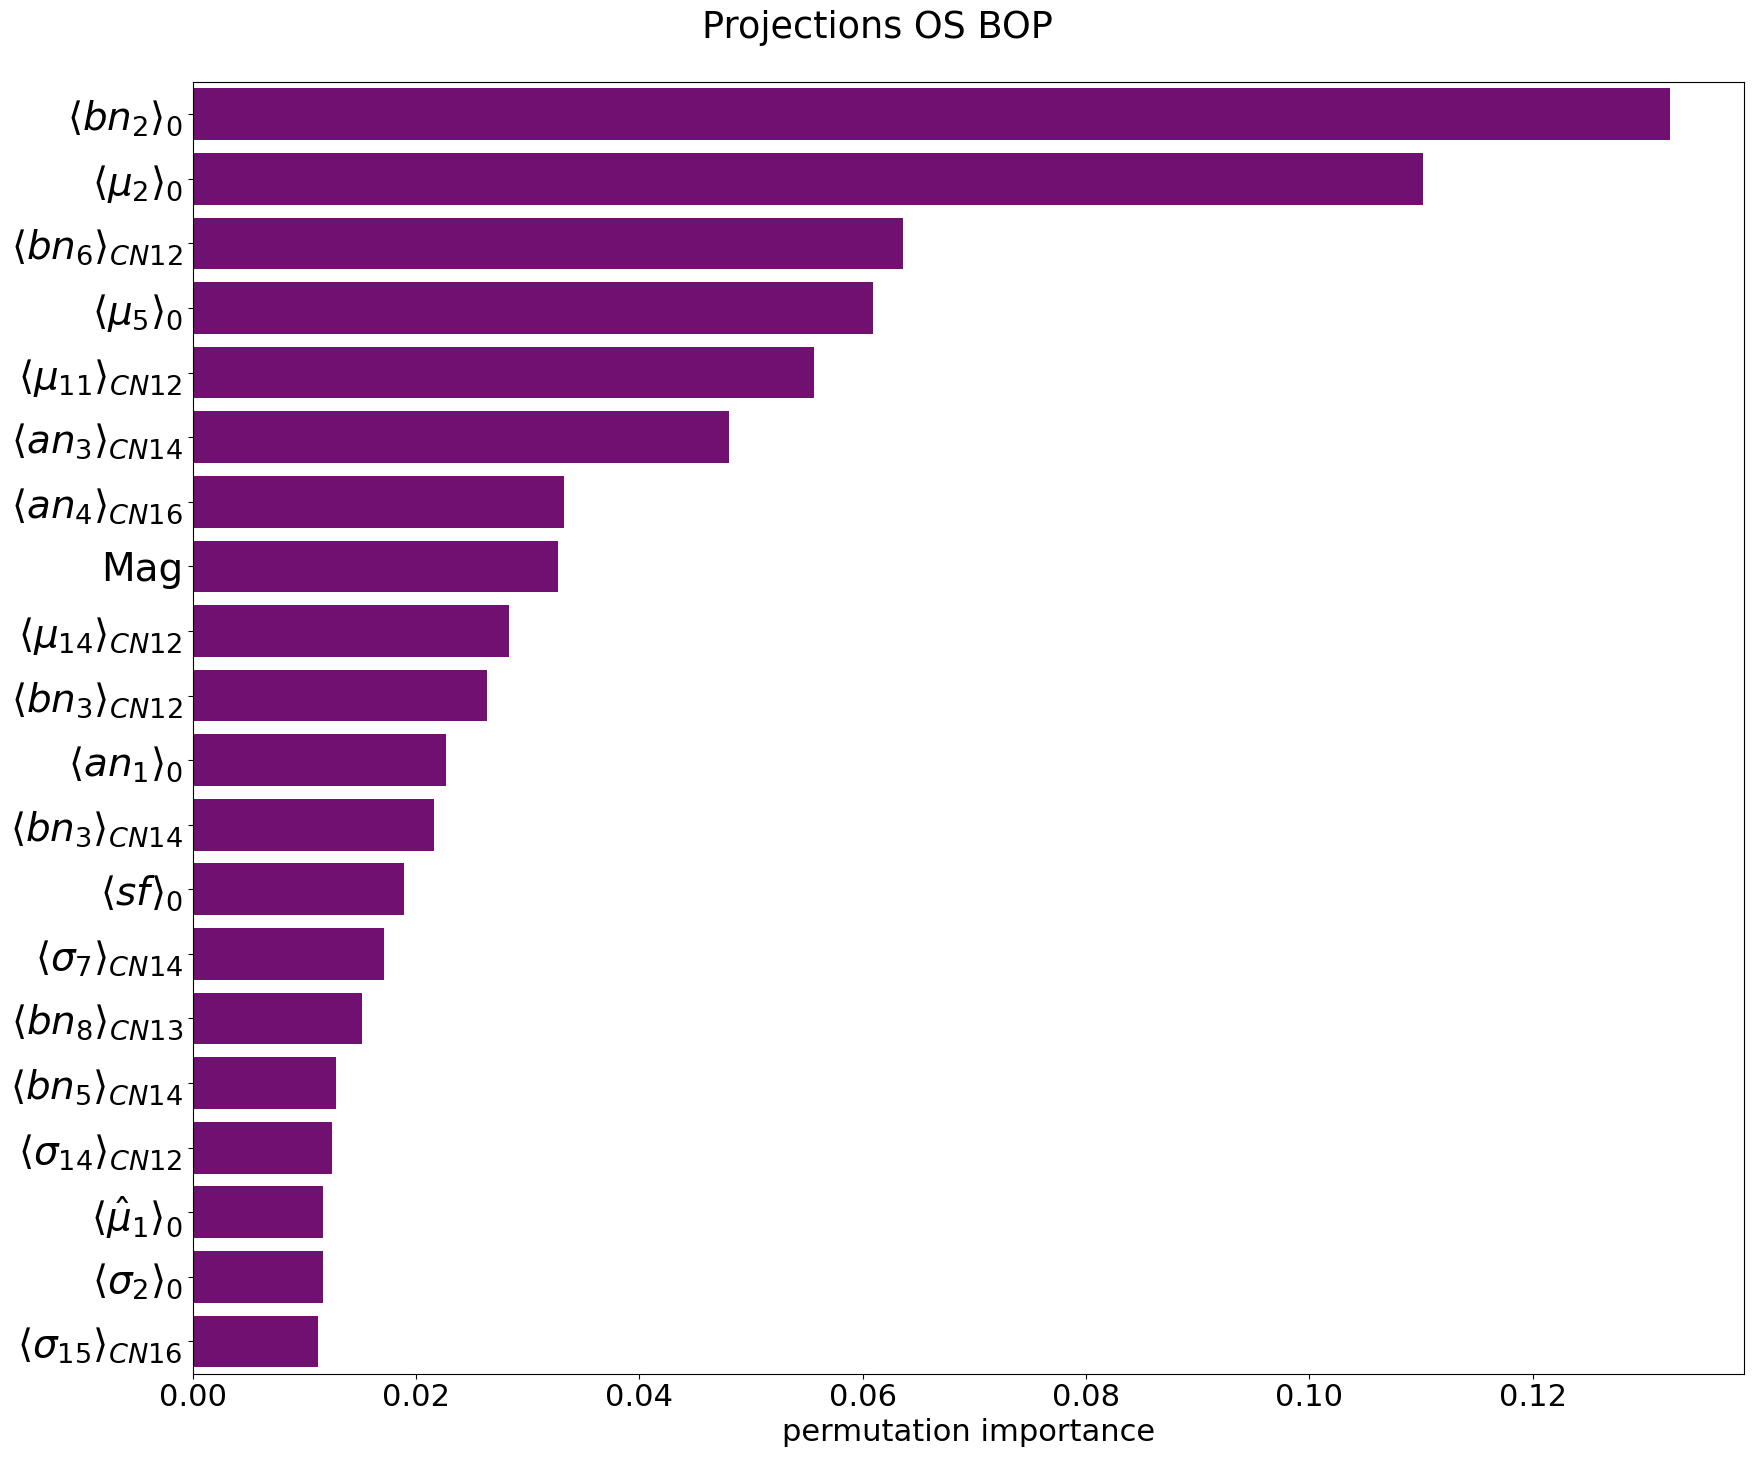

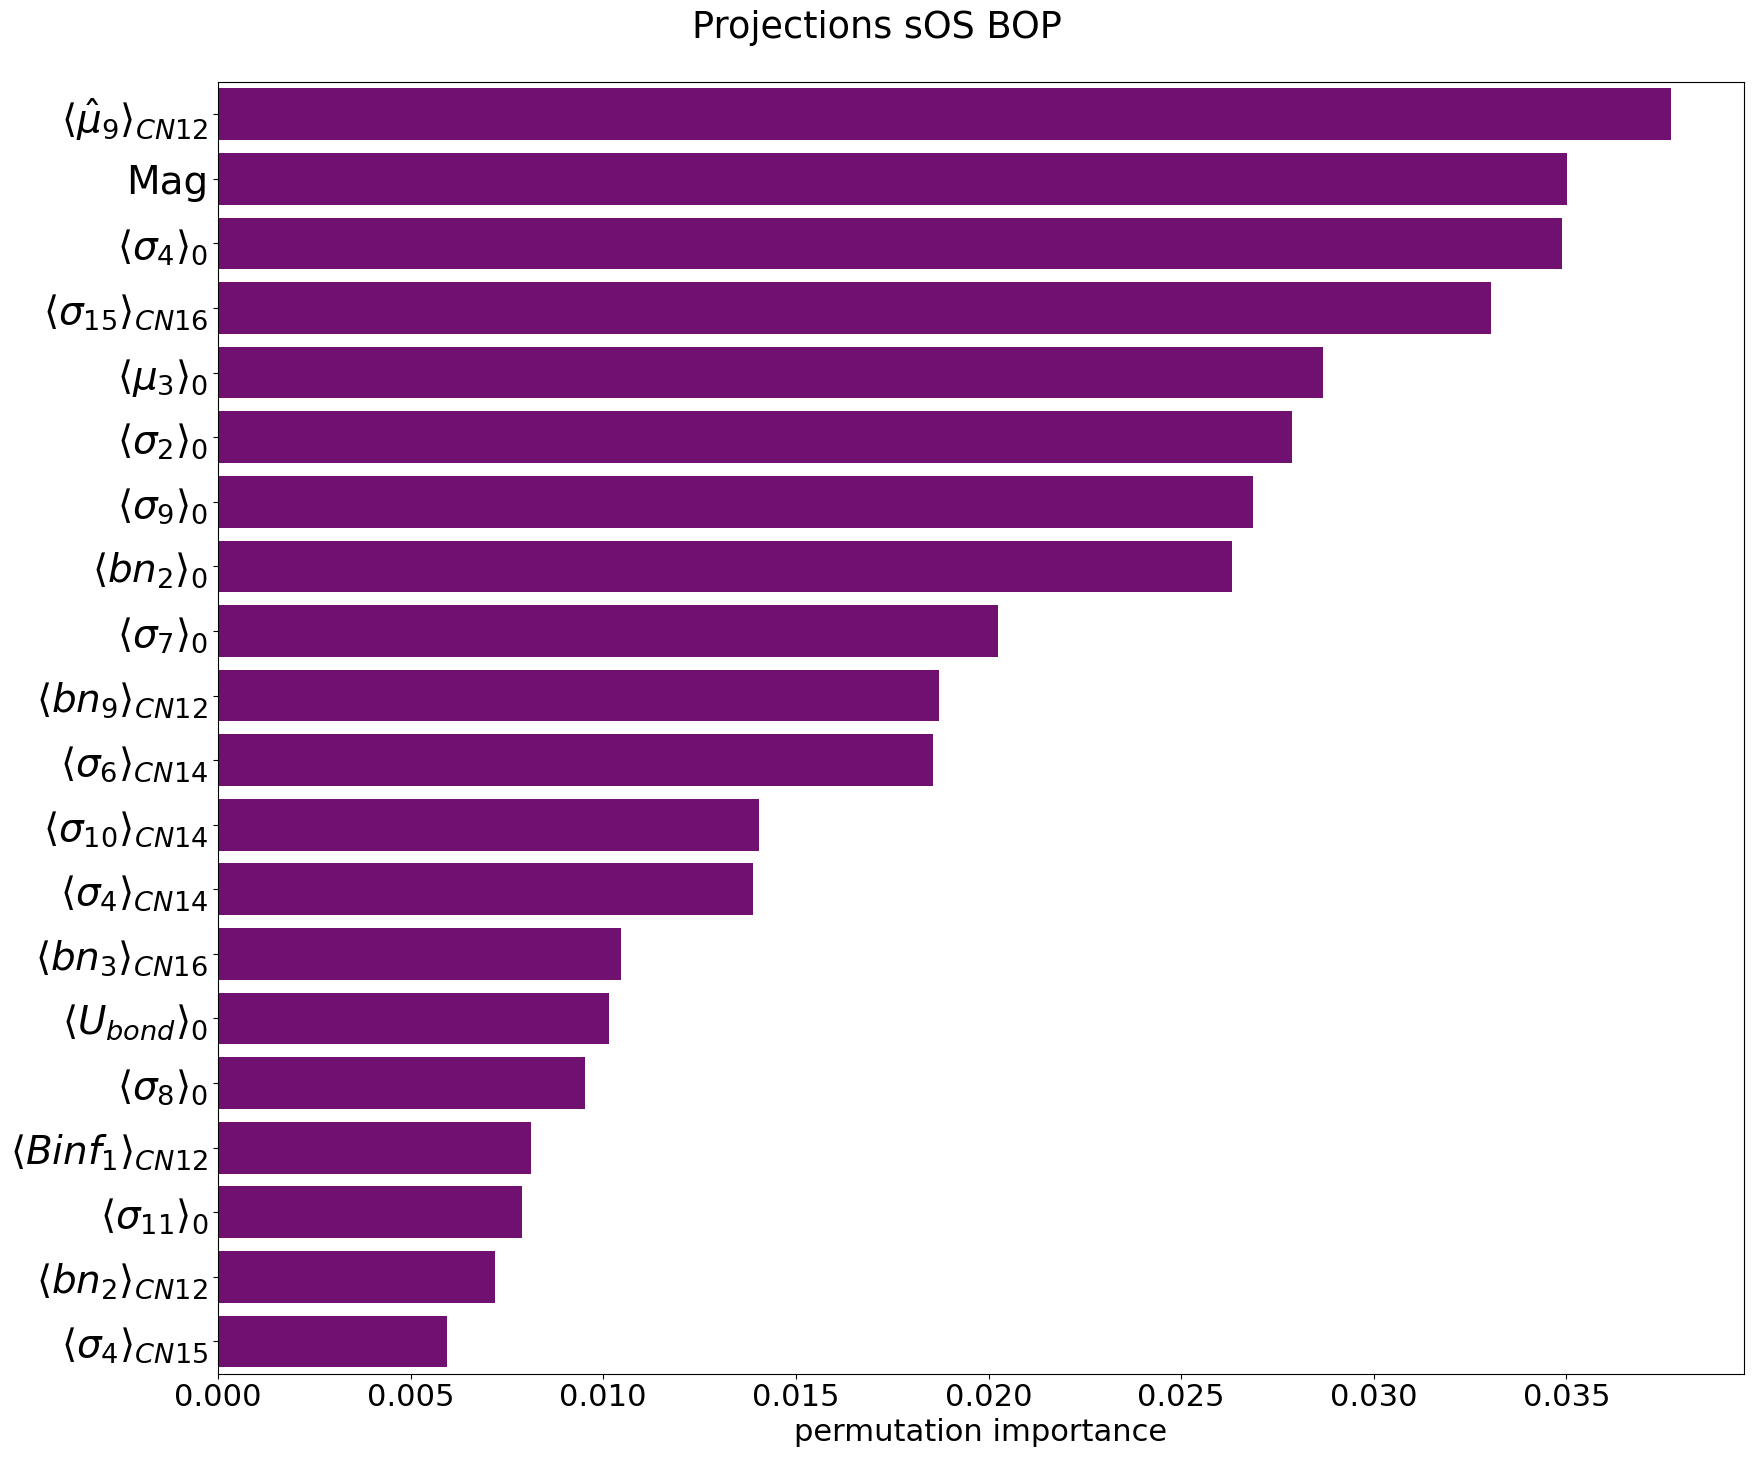

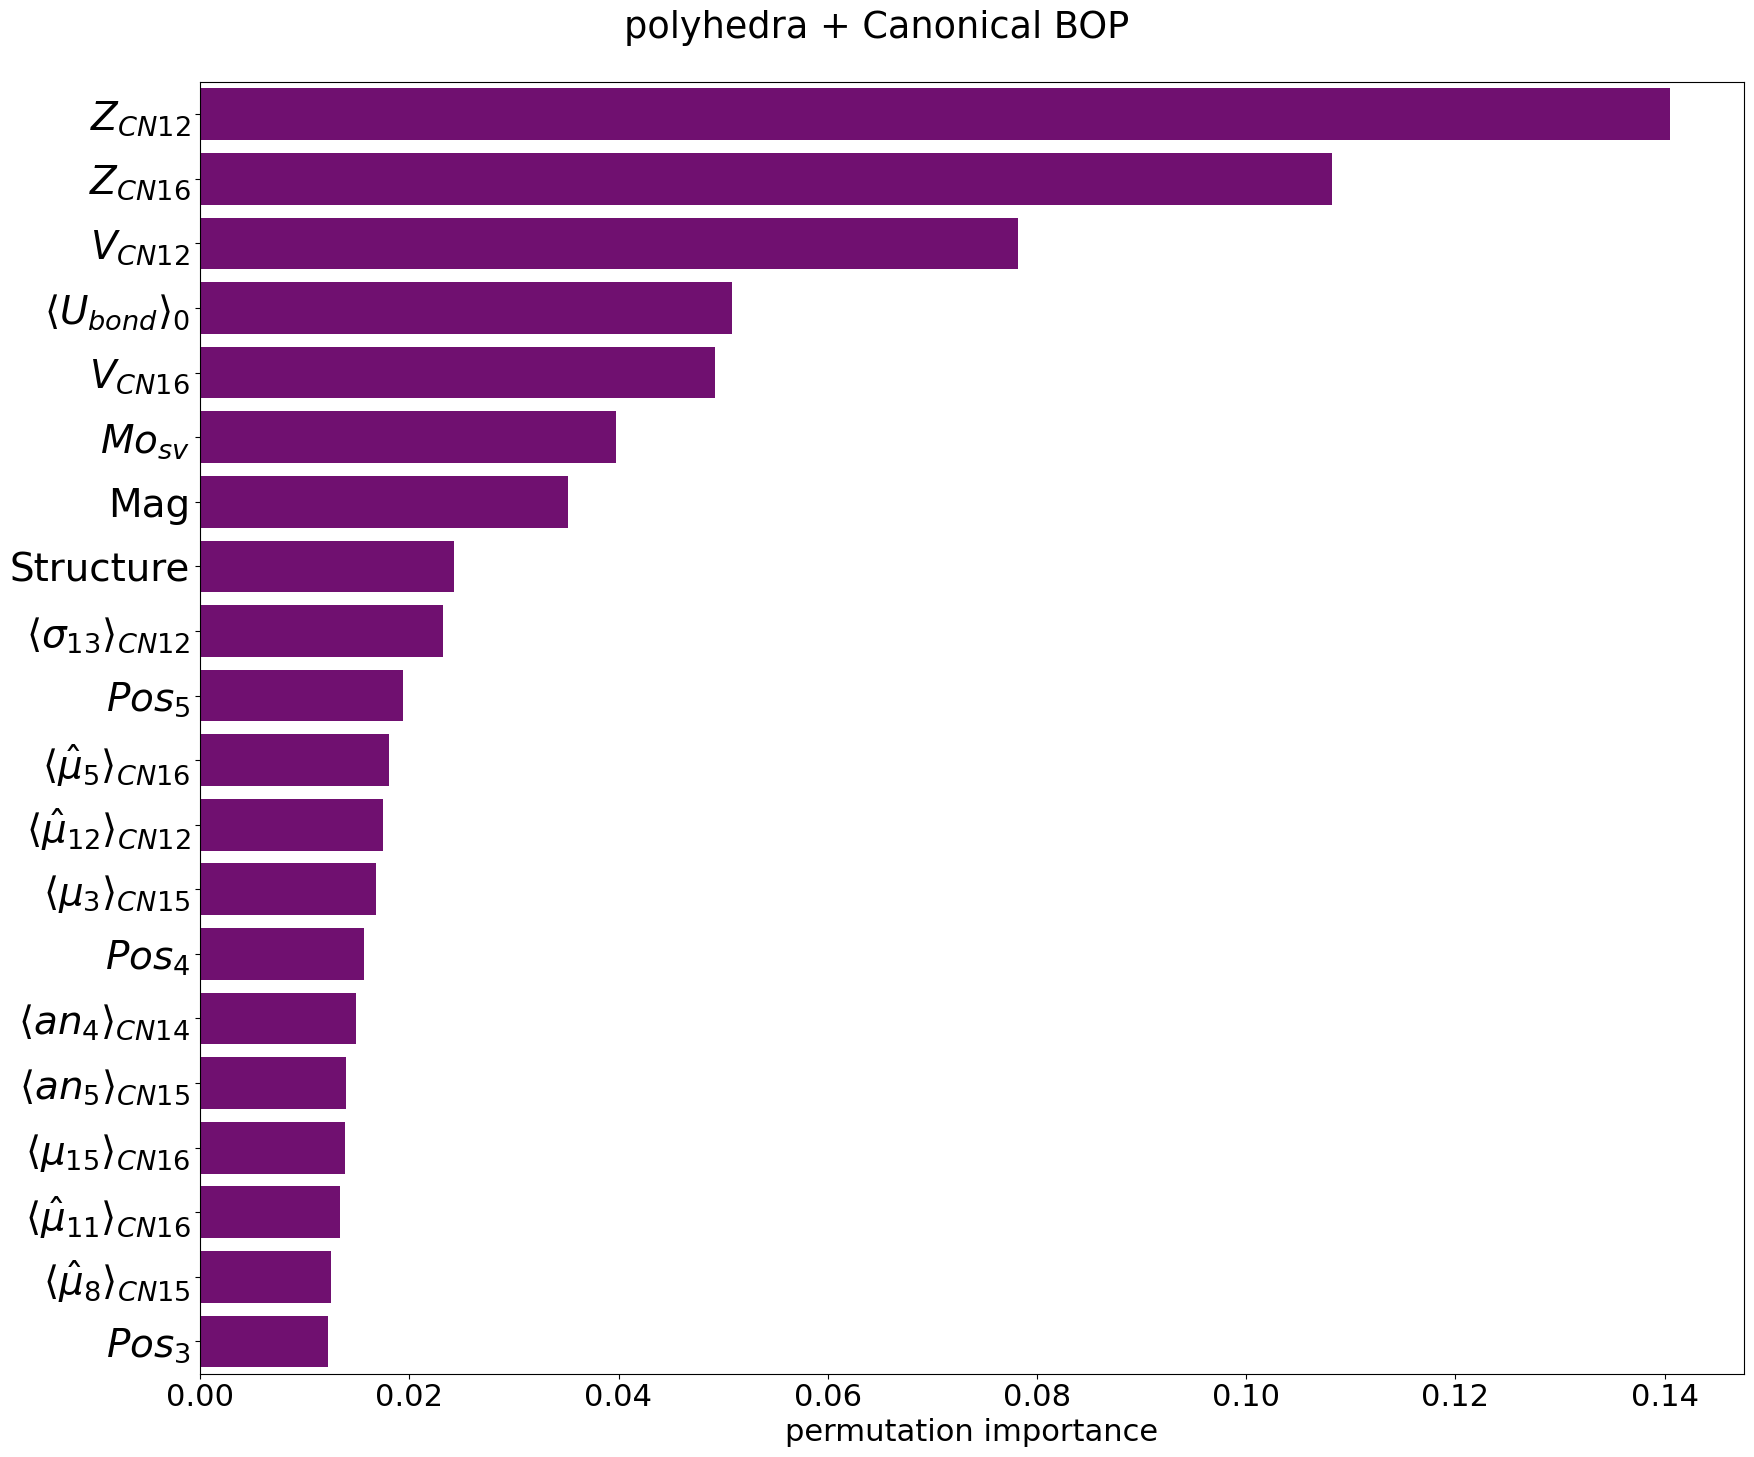

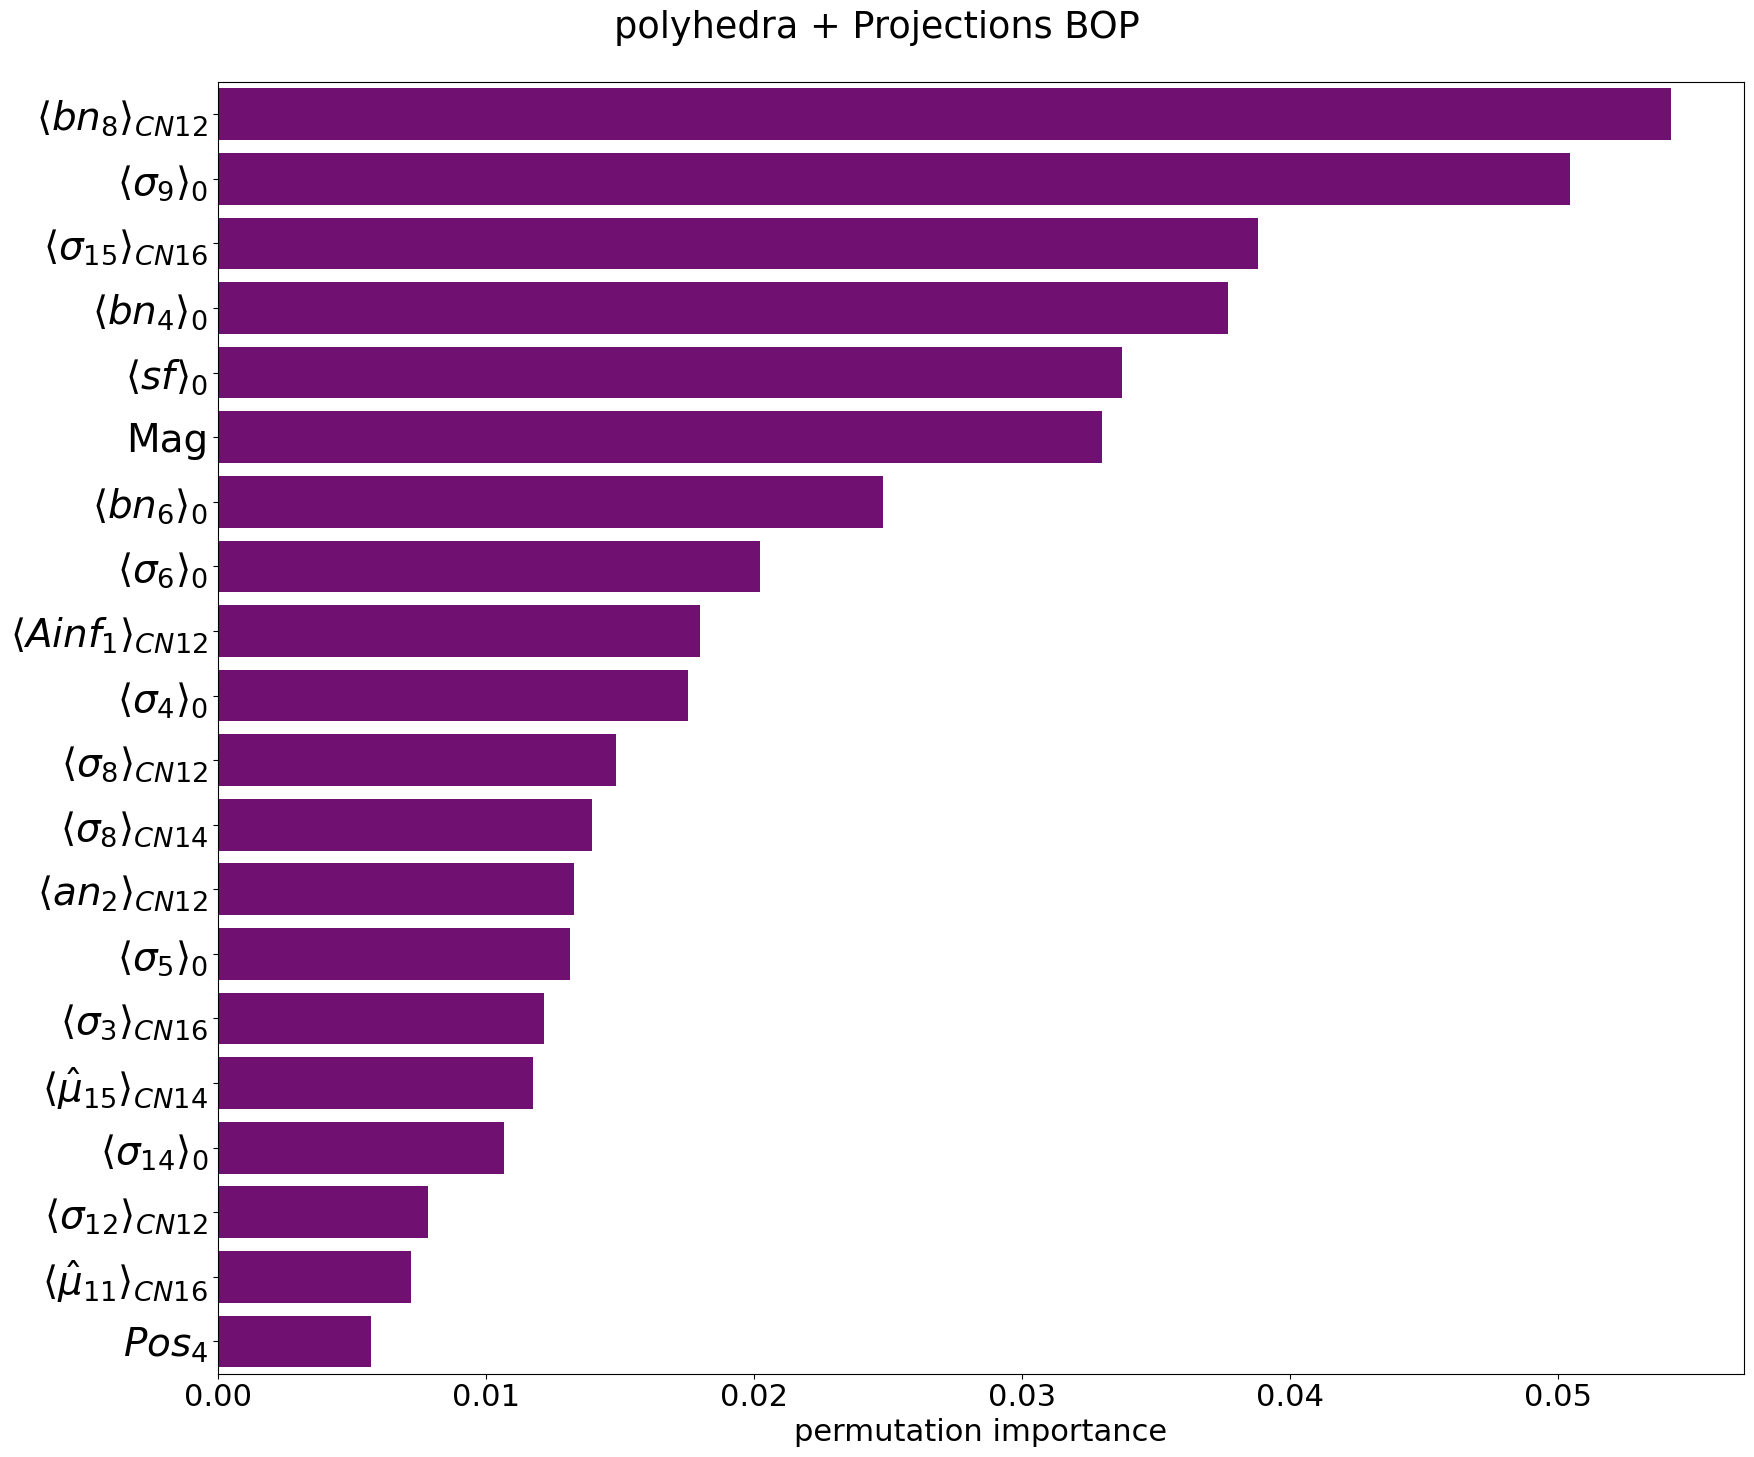

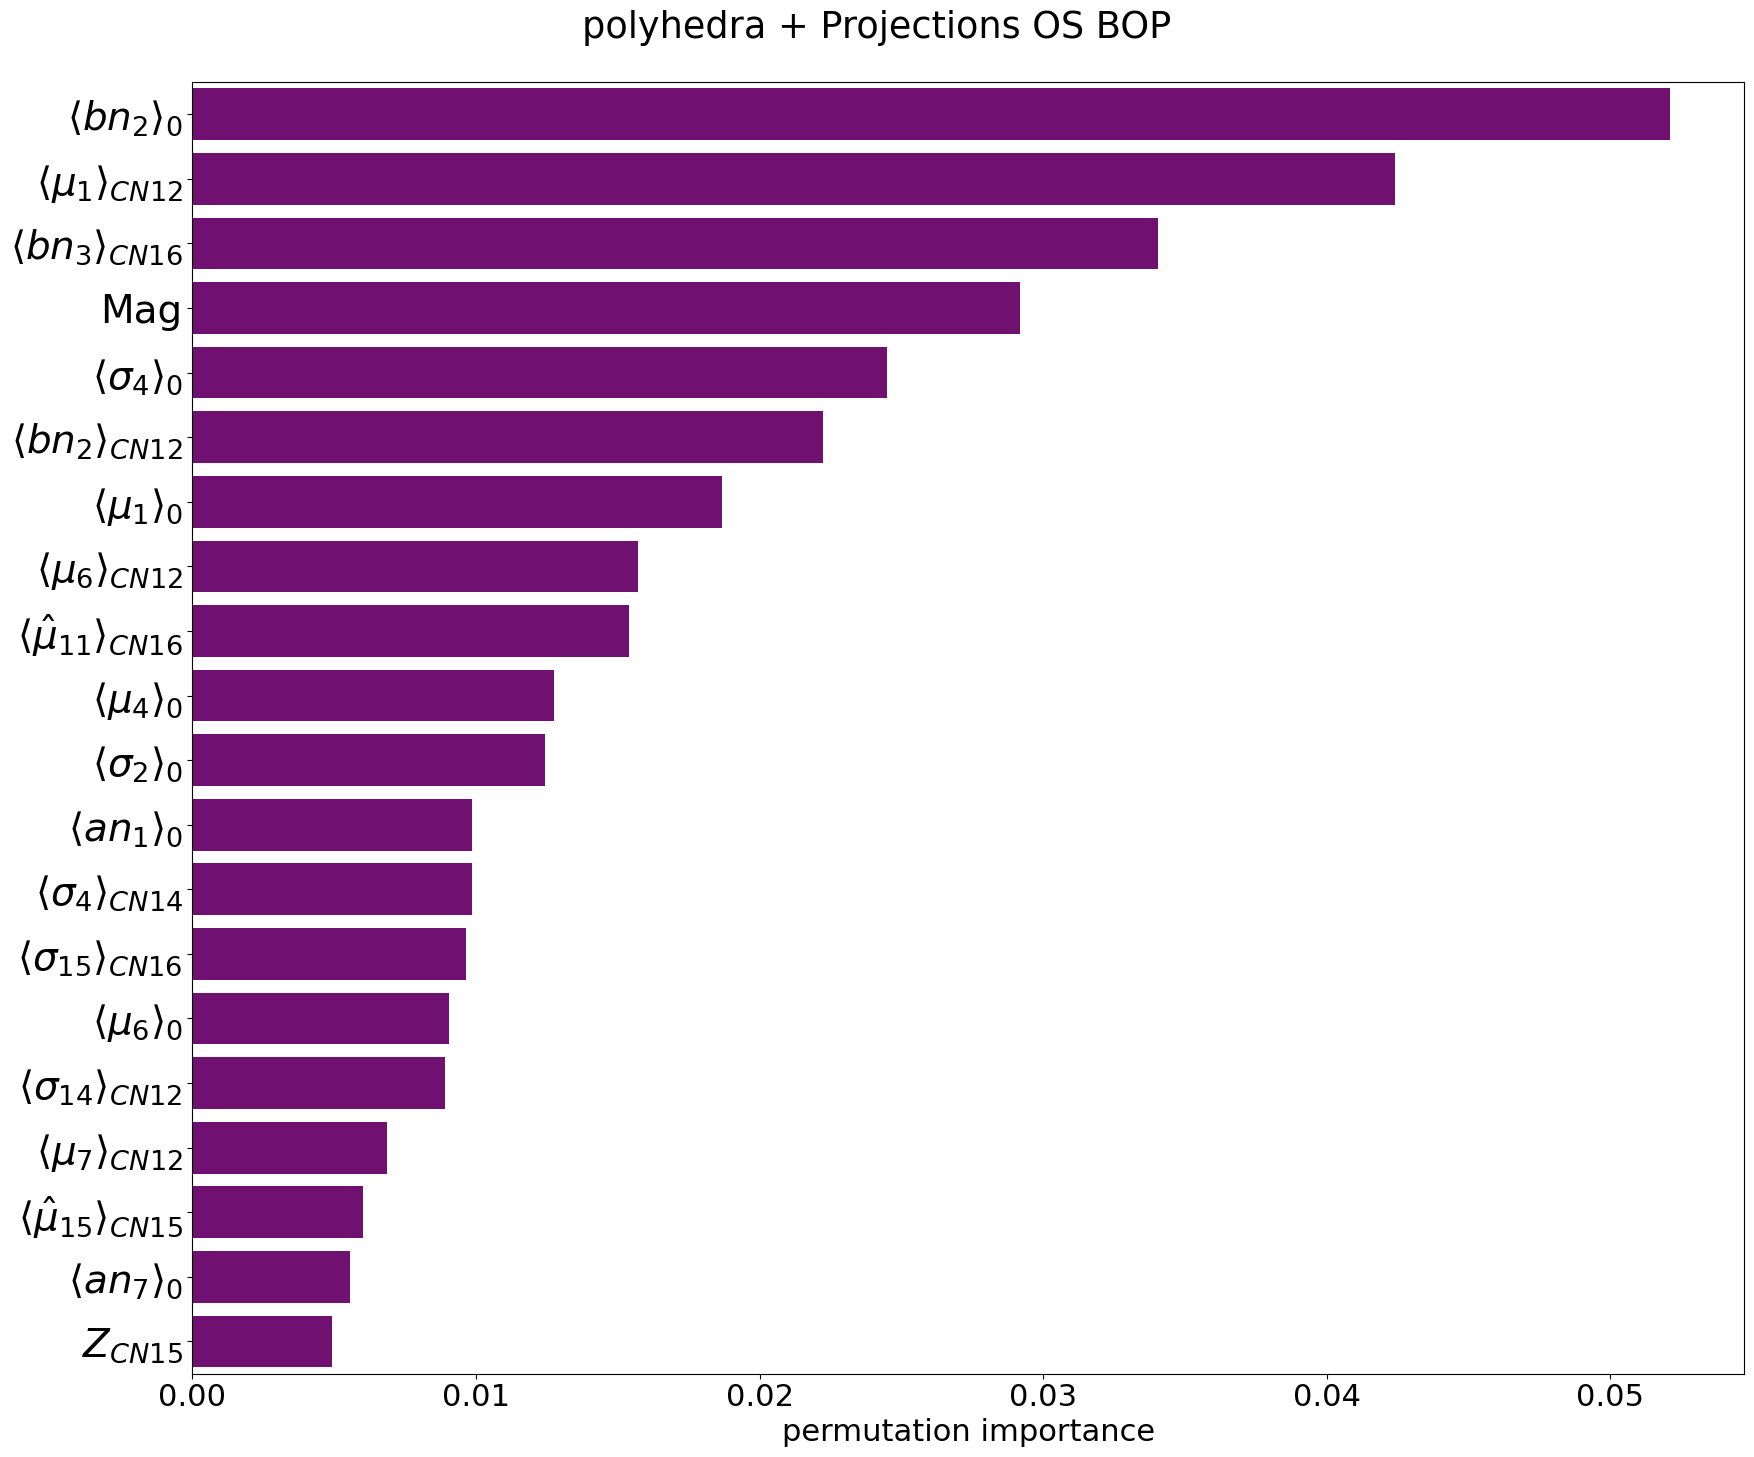

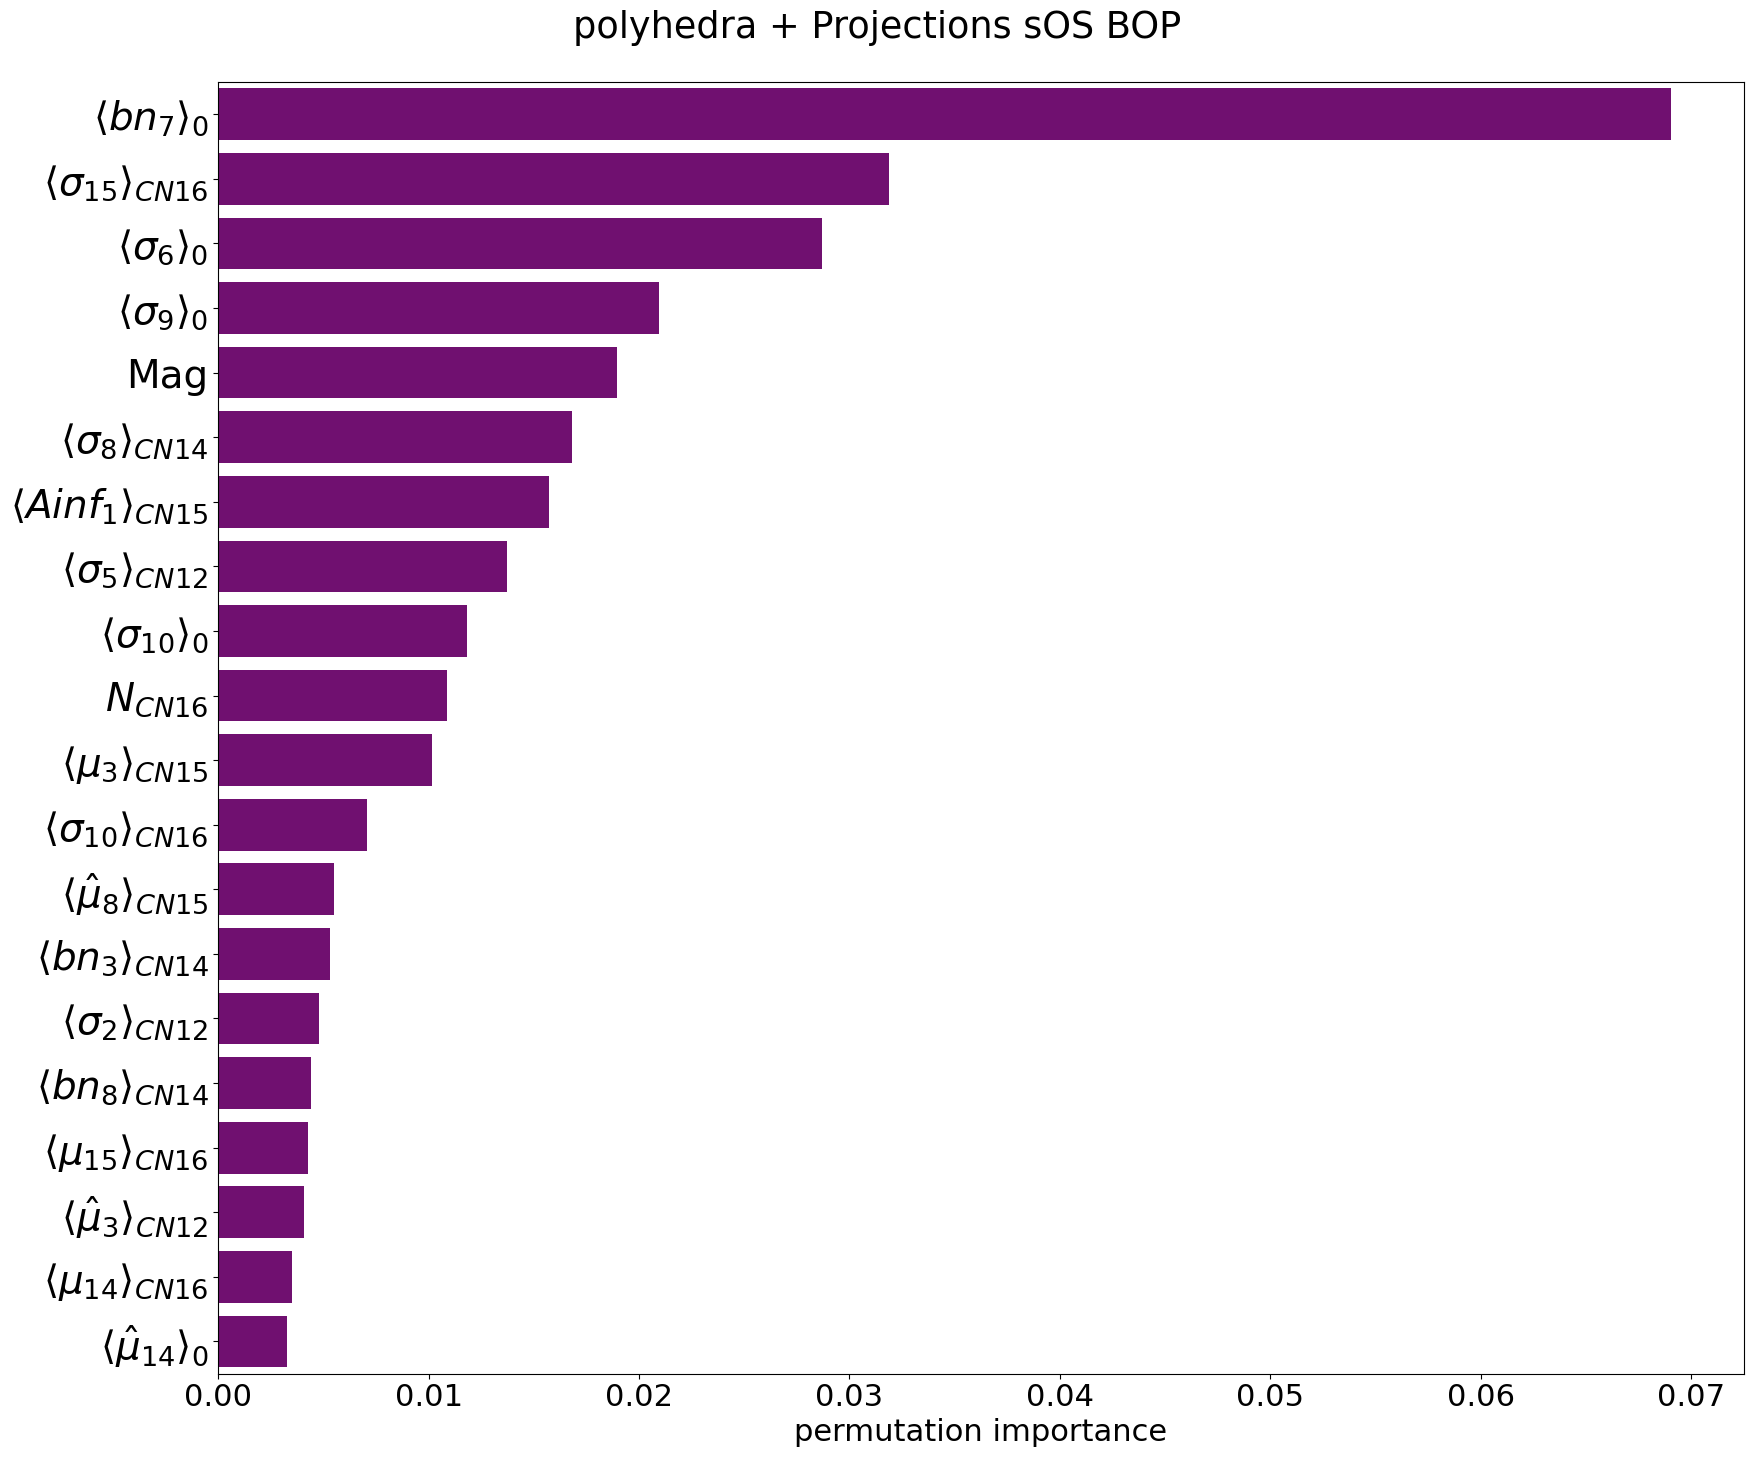

In [81]:
#for (model, name), timp in importances.items():
for (model, name), timp in importances.items(): #['Projections OS BOP', 'dataset + Projections OS BOP']:
#    pimp = timp[timp.index != 'Mag']
    fig, ax = plt.subplots(figsize=(18, 15))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels, fontsize=28)
    fig.suptitle(name.replace('dataset', 'polyhedra'))
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.eps')

# Errors by phase  

In [82]:
combi = (ModelName, 'Projections sOS BOP')

In [83]:
model = OptimalFittedModels[combi]

In [84]:
nselected = FCresults[combi]['test'].argmin()

In [85]:
selected = FCresults[combi].index[:nselected]

In [86]:
predictions = model.predict(DS.Features[combi[1]][selected])

In [87]:
train_errors = np.abs(predictions - DS.target)

In [88]:
rmse = {}

In [89]:
for phase in DS.BS.Phase.unique():
    thiserrors = train_errors[DS.BS.Phase == phase]**2
    rmse[phase] =  np.sqrt(thiserrors.sum()/len(thiserrors))*1000

In [90]:
rmse

{'C36': 30.732802099060216,
 'chi': 19.7379928057643,
 'sigma': 22.267355089511078,
 'hcp': 25.138789459785666,
 'mu': 30.348394836983815,
 'fcc': 18.45463263867396,
 'C14': 29.247237556235277,
 'C15': 27.025242121254067,
 'bcc': 14.6957829994281,
 'A15': 30.899941809445107,
 'R': 31.293381643140897}

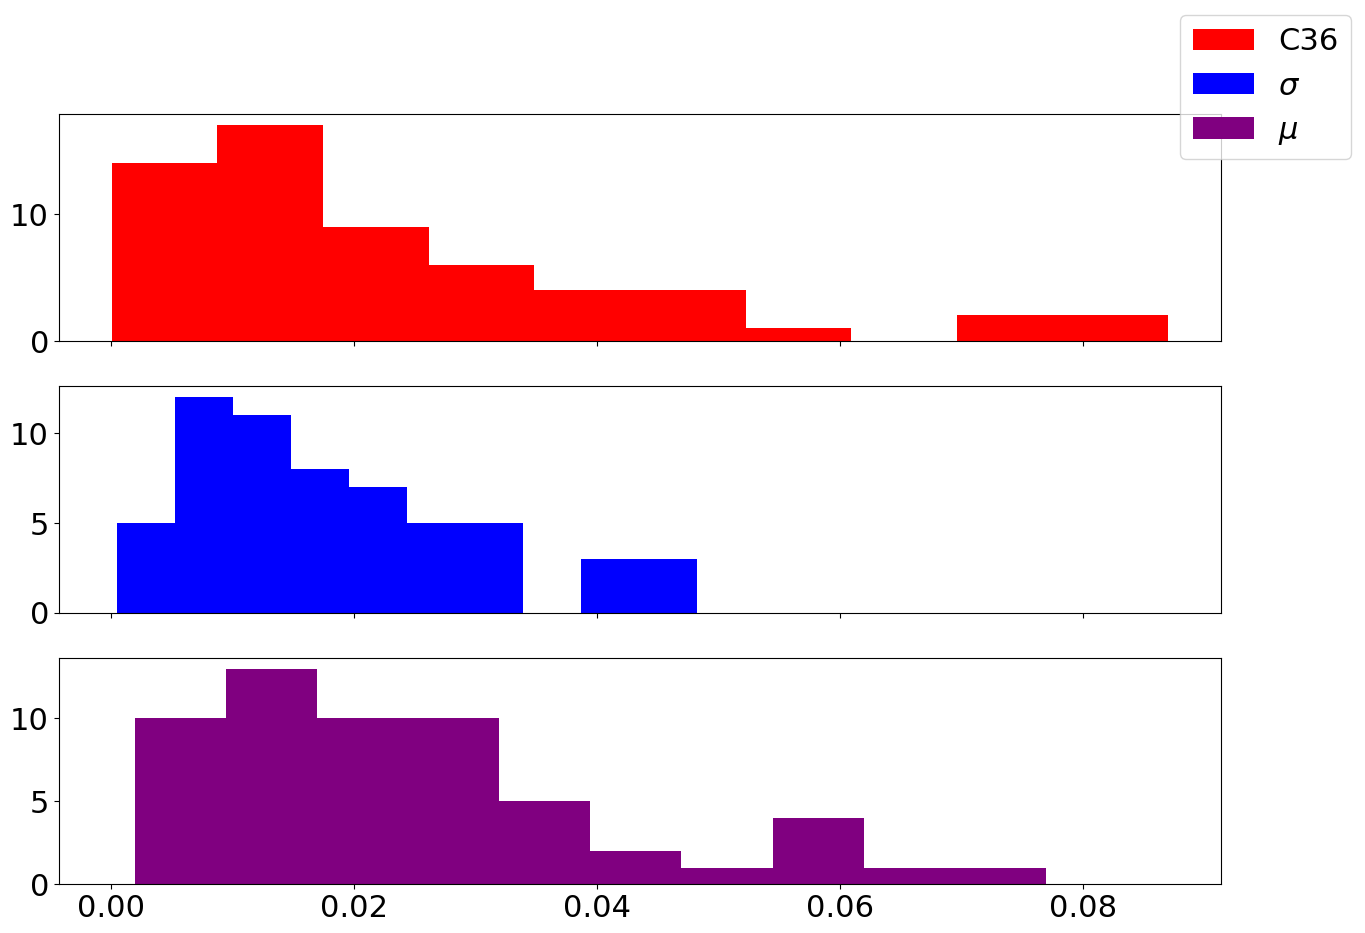

In [91]:
fig, ax = plt.subplots(3, 1, sharex = True)
tphase = ax[0].hist(train_errors[DS.BS.Phase == 'C36'], bins=10, color='red', label='C36')
tphase = ax[1].hist(train_errors[DS.BS.Phase == 'sigma'], bins=10,color='blue', label = r'$\sigma$')
tphase = ax[2].hist(train_errors[DS.BS.Phase == 'mu'], bins=10, color='purple', label = r'$\mu$')
fig.legend()

# convex hulls (binaries only)

In [92]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [93]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [94]:
components = DS.components

In [95]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [96]:
predictedBS['EF'] = Prediction[combi]

In [97]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

PhaseBS = {phase: DS.BS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

points = P.get_x_ef_points(PhaseBS, components)
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False)

In [98]:
PredPhaseBS = {}
Predverts = {}
Predchulls = {}
Predphasepoints = {}

PredPhaseBS = {phase: predictedBS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

predpoints = P.get_x_ef_points(PredPhaseBS, components)
predchulls = P.get_convex_hulls(PredPhaseBS, components, return_points = False)

In [99]:
iwanttoplot = ['R', 'mu', 'C14', 'C36','sigma']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


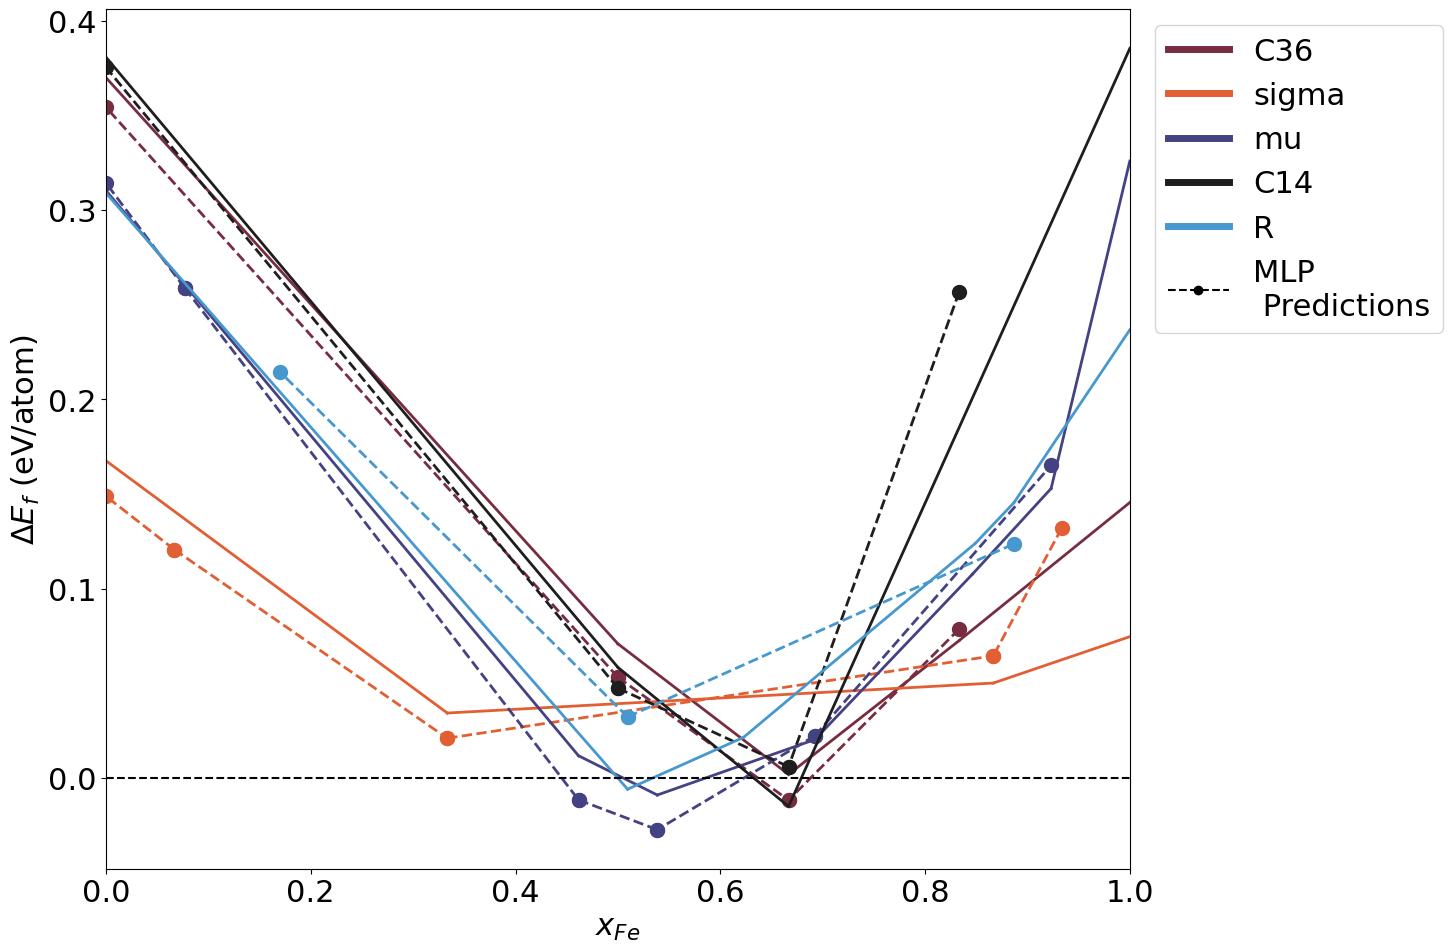

In [100]:
pallette = sns.color_palette("icefire", n_colors=len(iwanttoplot))
colors = {phase: color for phase, color in zip(iwanttoplot, pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    if phase not in iwanttoplot:
        continue
    for visible_facet in chull.simplices[chull.good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase], lw=2)
    handles.append(l[0])
    labels.append(phase)
    for visible_facet in predchulls[phase].simplices[predchulls[phase].good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(predchulls[phase].points[visible_facet,0], predchulls[phase].points[visible_facet,1],'--o', color=colors[phase], lw=2, ms=10)
leg = ax.legend(handles +[Line2D([],[], linestyle='--',marker='o', color='black')], labels+[f'{ModelName} \n Predictions'], bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines()[:-1] ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')
ax.axhline(color='black', linestyle='--')
ax.set_xlim([0,1])
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(os.path.join(DS.dataset, 'graphs',f'{DS.dataset}_{nameforfile}_ConvxHullsFinal.eps' ))